# Integrated Test — Does B's Elaborative Rehearsal Improve QA Accuracy?

`03`'s baseline established `chunked_sequential` as a plain, uncompressed
control: raw chunks shown one at a time (up to 4), no rehearsal applied. Its
own conclusion was explicit — chunked_sequential is "the uncompressed control
condition the project's actual rehearsal/gisting pipeline... needs to beat in
order to justify itself." `07b` finished training that pipeline (B, stage 2).
This notebook is that comparison.

## What changes, what doesn't

Same genres, same corpora, same questions, same `paginate_semantic` chunks,
same `call_chat`, same scoring, same 4-chunk exploration budget as `03`'s
`chunked_sequential` — so the comparison isolates one variable. The only
difference: at each step, instead of showing the QA model the raw chunk text,
this shows the **rolling `ThreadMemory` state** after B's trained stage-2
checkpoint has read that chunk (via `rehearse_elaborative`) — retrieve related
prior threads, generate a gist conditioned on them, write back.

## Scope, given the deadline

- Tests B (elaborative rehearsal) only — not A (maintenance) or C (testing
  effect). Those would need their own conditions in a fuller `10`.
- Reuses `03`'s already-completed closed_book/full_context/chunked_sequential
  results rather than re-running them — only the new condition spends fresh
  API budget.
- `07b`'s own result: stage 2 has a real, positive collapse signature
  (drop +0.111, C-DIC Fig. 2(a)-style) despite being 5-6x better than stage 1
  at every age. This is not a test of a checkpoint known to be flawless — it
  is the honest next question: does an imperfect-but-real improvement in
  retention actually move the needle on the task the whole pipeline exists
  for?


In [19]:
import os
import re
import sys
import threading
import time
from collections import deque
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

root = Path.cwd()
while not (root / "src").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

from src.notebook_setup import setup_project

setup_project()
API_KEY_SET = bool(os.environ.get("NVIDIA_NIM_API_KEY"))

import pandas as pd
import yaml
from tqdm.auto import tqdm
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

from src.pipeline.embeddings import embed_texts, load_config as load_embed_config
from src.pipeline.rehearsal import rehearse_elaborative
from src.pipeline.types import Chunk

STAGE2_DIR = Path("experiments/rehearsal_elaborative_stage2")
STAGE2_READY = STAGE2_DIR.exists()
STAGE2_STATUS = "ready" if STAGE2_READY else "MISSING \u2014 run 07b first"
print(f"stage-2 checkpoint: {STAGE2_STATUS}")


project root: /Users/lucyroh/Desktop/STUDY/Data Projects/rehearse-then-recall
.env loaded: success ✅
NVIDIA_NIM_API_KEY: set ✅
stage-2 checkpoint: ready


## 1. Genres, corpora, questions — identical to `03`

Same `GENRES` dict, same files. Loaded independently here rather than
imported from `03` (that notebook has no importable module, just cells) —
kept byte-identical on purpose so the eval set matches exactly.


In [20]:
GENRES = {
    "wiki": {
        "corpus_path": "data/processed/wiki_eval/wiki_eval_corpus.txt",
        "questions_path": "data/sample/wiki_eval_questions.csv",
        "format": "extractive",
    },
    "news": {
        "corpus_path": "data/processed/news_eval/news_eval_corpus.txt",
        "questions_path": "data/sample/news_eval_questions.csv",
        "format": "extractive",
    },
    "novel": {
        "corpus_path": "data/processed/narrativeqa_length_stress/novel_eval_corpus.txt",
        "questions_path": "data/sample/narrativeqa_novel_eval_questions.csv",
        "format": "extractive",
    },
    "caselaw": {
        "corpus_path": "data/processed/caselaw_eval/caselaw_eval_corpus.txt",
        "questions_path": "data/sample/caselaw_eval_questions.csv",
        "format": "multiple_choice",
    },
}

corpora: dict[str, str] = {}
questions: dict[str, pd.DataFrame] = {}

for genre, cfg in GENRES.items():
    with open(cfg["corpus_path"], encoding="utf-8") as f:
        corpora[genre] = f.read()
    qdf = pd.read_csv(cfg["questions_path"], encoding="utf-8-sig")
    questions[genre] = qdf
    print(f"{genre:10} format={cfg['format']:16} corpus={len(corpora[genre].split()):>6} words, questions={len(qdf):>4}")


wiki       format=extractive       corpus= 14934 words, questions= 100
news       format=extractive       corpus= 50443 words, questions= 200
novel      format=extractive       corpus= 59027 words, questions=  79
caselaw    format=multiple_choice  corpus= 54791 words, questions= 200


## 2. Chunking — identical to `03`

Same `paginate_semantic` call, same config. Chunk boundaries are
embedding-based, so this has to use the same config `03` did or the two
notebooks would not be exploring the same chunk 1, chunk 2, etc.


In [21]:
chunks_by_genre: dict[str, list] = {}

if not API_KEY_SET:
    print("No NVIDIA_NIM_API_KEY \u2014 skipping chunk generation.")
else:
    from src.pipeline.chuncking import paginate_semantic, plain_text_to_paragraphs
    from src.pipeline.embeddings import embed_texts as _embed_texts_for_chunking, load_config as _load_chunk_embed_config

    chunk_cfg = yaml.safe_load(open("configs/chunking.yaml", encoding="utf-8"))
    chunk_embed_cfg = _load_chunk_embed_config("configs/importance_filter.yaml")

    for genre, text in corpora.items():
        paragraphs = plain_text_to_paragraphs(text)
        chunks_by_genre[genre] = paginate_semantic(
            paragraphs,
            min_words=chunk_cfg["min_words"],
            max_words=chunk_cfg["max_words"],
            granularity="paragraph",
            config=chunk_embed_cfg,
            embed_fn=_embed_texts_for_chunking,
        )
        print(f"{genre:10} chunks: {len(chunks_by_genre[genre])}")


wiki       chunks: 107
news       chunks: 390
novel      chunks: 498
caselaw    chunks: 400


## 3. Precompute B's rolling memory state, per genre

`curate_document_threaded`/`rehearse_elaborative` are query-agnostic —
enforced by a dedicated test (`test_curate_document_threaded_is_query_agnostic`).
What B reads and compresses does not depend on which question will later be
asked against it. So the rolling memory state after chunk 1, chunk 2, chunk 3,
chunk 4 is the same for every question in a genre — computing it once per
genre and reusing it across all questions is correct, not an approximation,
and turns what would otherwise be thousands of redundant rehearsal passes
into 4 chunks x 4 genres = 16.

Only the first `MAX_CHUNKS_EXPLORE` chunks matter — `chunked_sequential`
never looks past chunk 4 either, so B never needs to process further than the
baseline it is being compared against.


In [22]:
MAX_CHUNKS_EXPLORE = 4  # matches 03's budget exactly

memory_states_by_genre: dict[str, list[str]] = {}

if not (API_KEY_SET and STAGE2_READY):
    print("Skipping \u2014 need both an API key and the stage-2 checkpoint.")
else:
    embed_cfg = load_embed_config()
    stage2_tokenizer = AutoTokenizer.from_pretrained(STAGE2_DIR)
    stage2_model = AutoModelForSeq2SeqLM.from_pretrained(STAGE2_DIR)

    for genre, chunk_list in chunks_by_genre.items():
        explore_chunks = chunk_list[:MAX_CHUNKS_EXPLORE]
        rehearsal_chunks = [Chunk(text=c.text, index=i) for i, c in enumerate(explore_chunks)]
        _, records = rehearse_elaborative(
            rehearsal_chunks, stage2_model, stage2_tokenizer, embed_cfg, embed_texts,
            record_memory_state=True,
        )
        memory_states_by_genre[genre] = [r.memory_state for r in records]
        lengths = [len(s.split()) for s in memory_states_by_genre[genre]]
        print(f"{genre:10} memory state lengths (words) by step: {lengths}")


wiki       memory state lengths (words) by step: [53, 53, 106, 106]
news       memory state lengths (words) by step: [50, 100, 150, 200]
novel      memory state lengths (words) by step: [18, 58, 98, 134]
caselaw    memory state lengths (words) by step: [37, 74, 111, 148]


## 4. NIM chat API call

Same implementation as `03` (sliding-window rate limiter, backoff,
thread-local usage tracking) — duplicated rather than imported, matching this
project's existing pattern (`02`/`03` each already have their own copy;
promoting it to `src/` is flagged there as future work, not something this
notebook needs to block on).


In [23]:
QA_MODEL = "meta/llama-3.1-8b-instruct"
QA_API_KEY = os.environ.get("NVIDIA_NIM_API_KEY")
_CHAT_API_URL = "https://integrate.api.nvidia.com/v1/chat/completions"
_RETRYABLE_STATUS = {429, 500, 502, 503, 504}

_usage_local = threading.local()


def last_chat_usage() -> dict | None:
    return getattr(_usage_local, "value", None)


class RateLimiter:
    def __init__(self, max_per_minute: int):
        self.max_per_minute = max_per_minute
        self._lock = threading.Lock()
        self._timestamps: deque = deque()

    def acquire(self) -> None:
        while True:
            with self._lock:
                now = time.time()
                while self._timestamps and now - self._timestamps[0] > 60:
                    self._timestamps.popleft()
                if len(self._timestamps) < self.max_per_minute:
                    self._timestamps.append(now)
                    return
                sleep_for = 60 - (now - self._timestamps[0])
            time.sleep(max(sleep_for, 0.1))


_rate_limiter = RateLimiter(max_per_minute=30)


def call_chat(messages: list[dict], model: str, api_key: str, timeout: float = 120.0, max_retries: int = 3) -> str:
    last_error: Exception | None = None
    for attempt in range(max_retries + 1):
        _rate_limiter.acquire()
        try:
            response = requests.post(
                _CHAT_API_URL,
                headers={"Authorization": f"Bearer {api_key}", "Accept": "application/json"},
                json={"model": model, "messages": messages, "temperature": 0.0},
                timeout=timeout,
            )
        except (requests.exceptions.Timeout, requests.exceptions.ConnectionError) as e:
            last_error = e
            if attempt < max_retries:
                time.sleep(3.0 * (attempt + 1))
                continue
            raise RuntimeError(f"NIM chat API call failed (retries exhausted): {e}") from e

        if response.status_code == 200:
            payload = response.json()
            _usage_local.value = payload.get("usage")
            return payload["choices"][0]["message"]["content"]
        if response.status_code in _RETRYABLE_STATUS and attempt < max_retries:
            time.sleep(3.0 * (attempt + 1))
            continue
        raise RuntimeError(f"NIM chat API failed ({response.status_code}): {response.text}")

    raise RuntimeError(f"NIM chat API call failed (retries exhausted): {last_error}")


## 5. Scoring + message builders — identical to `03`

Same `is_correct`, same question-turn prompt. `run_chunked_sequential_rehearsal`
in §6 is the only new function.


In [24]:
import requests

_NO_TOOLS_SENTENCE = (
    "Do not use web search or any external tool \u2014 answer using only the information "
    "given to you (or your own prior knowledge)."
)
_OPEN_ANSWER_INSTRUCTION = "Answer with only the answer itself, as briefly as possible (a word or short phrase). No other explanation."
_MC_ANSWER_INSTRUCTION = "Answer with only the number (1-5) of the correct option. No other explanation."
_CONTINUE_SIGNAL = "CONTINUE"


def normalize_answer(text: str) -> str:
    text = re.sub(r"[\s\.,!?'\"()\[\]{}]", "", text)
    return text.lower()


def is_correct_extractive(prediction: str, reference: str) -> bool:
    norm_ref = normalize_answer(reference)
    if not norm_ref:
        return False
    return norm_ref in normalize_answer(prediction)


def parse_option_number(text: str) -> int | None:
    match = re.search(r"[1-5]", text)
    return int(match.group()) if match else None


def is_correct(genre: str, row: pd.Series, prediction: str | None) -> bool:
    if prediction is None:
        return False
    if GENRES[genre]["format"] == "multiple_choice":
        pred_idx = parse_option_number(prediction)
        return pred_idx is not None and (pred_idx - 1) == row["correct_option_index"]
    return is_correct_extractive(prediction, row["answer"])


def _question_turn(genre: str, row: pd.Series) -> dict:
    if GENRES[genre]["format"] == "multiple_choice":
        options_text = "\n".join(f"{i + 1}) {row[f'option_{i}']}" for i in range(5))
        content = f"{_MC_ANSWER_INSTRUCTION}\n\nQuestion: {row['question']}\n{options_text}"
    else:
        content = f"{_OPEN_ANSWER_INSTRUCTION}\n\nQuestion: {row['question']}"
    return {"role": "user", "content": content}


## 6. The new condition — chunked_sequential, B-compressed

Identical loop structure to `03`'s `run_chunked_sequential`: same
early-stop/CONTINUE mechanism, same 4-step budget, same prompts. The only
change is what's shown at each step — B's compressed rolling memory state
(§3) instead of the raw chunk text.


In [25]:
def run_chunked_sequential_rehearsal(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Same shape as 03's run_chunked_sequential, except each step shows B's
    compressed rolling memory state instead of the raw chunk text."""
    fmt = GENRES[genre]["format"]
    answer_hint = "a number 1-5" if fmt == "multiple_choice" else "a short answer"
    states = memory_states_by_genre[genre]
    system = {
        "role": "system",
        "content": (
            f"{_NO_TOOLS_SENTENCE} You are an assistant that answers questions. You'll be shown a "
            f"running summary of the source text, updated one step at a time (up to {len(states)}). "
            f"After each step, if you're already confident, output {answer_hint}; if not yet confident "
            f"and want to see the next step, output only '{_CONTINUE_SIGNAL}'."
        ),
    }
    messages = [system, _question_turn(genre, row)]

    total_elapsed = 0.0
    total_tokens = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
    prediction = None
    steps_used = 0

    for i, state in enumerate(states):
        is_last = i == len(states) - 1
        instruction = (
            f"This is the last step you'll see \u2014 you must answer now ({answer_hint})."
            if is_last
            else f"If you can answer now, do so ({answer_hint}); otherwise output only '{_CONTINUE_SIGNAL}'."
        )
        messages.append(
            {"role": "user", "content": f"[step {i + 1}/{len(states)}]\n{state}\n\n{instruction}"}
        )

        t0 = time.time()
        reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
        total_elapsed += time.time() - t0
        steps_used = i + 1

        usage = last_chat_usage() or {}
        for key in total_tokens:
            total_tokens[key] += usage.get(key) or 0

        messages.append({"role": "assistant", "content": reply})

        candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
        looks_like_continue = fmt != "multiple_choice" and _CONTINUE_SIGNAL.lower() in reply.strip().lower()
        if fmt == "multiple_choice":
            if candidate is not None:
                prediction = str(candidate)
                break
        elif not looks_like_continue and candidate:
            prediction = candidate
            break

    return {
        "prediction": prediction,
        "api_calls": steps_used,
        "elapsed_seconds": round(total_elapsed, 1),
        "prompt_tokens": total_tokens["prompt_tokens"],
        "completion_tokens": total_tokens["completion_tokens"],
        "total_tokens": total_tokens["total_tokens"],
    }


## 7. Cost gate

579 questions x up to 4 QA calls each, same order of magnitude as `03`'s own
`chunked_sequential` run (~1 hour wall-clock there, dominated by the
100-200-question genres) — early-stop usually cuts this well short of the
worst case, as `03` found. Results checkpoint to a **separate** file so this
never touches `03`'s already-completed data.

Set `CONFIRM_SPEND = True` only after reading the count below.


In [26]:
CONDITION = "chunked_sequential_rehearsal"
RESULTS_PATH = "results/qa_stage2_rehearsal_condition.csv"
CONFIRM_SPEND = True  # <- flip to True to actually call the QA model

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions}, up to {4 * total_questions} QA calls (early-stop usually well under this)")
print(f"CONFIRM_SPEND = {CONFIRM_SPEND}")


questions: 579, up to 2316 QA calls (early-stop usually well under this)
CONFIRM_SPEND = True


In [27]:
def _run_one_question(genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_chunked_sequential_rehearsal(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": CONDITION,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {RESULTS_PATH} ({len(existing_df)} rows)")
else:
    existing_df = pd.DataFrame()

done_genres = set()
if len(existing_df):
    for genre, group in existing_df.groupby("genre"):
        if len(group) >= len(questions[genre]):
            done_genres.add(genre)

if not CONFIRM_SPEND:
    print("skipped \u2014 CONFIRM_SPEND is False")
    rehearsal_df = existing_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    rehearsal_df = existing_df
else:
    MAX_WORKERS = 8
    results = existing_df.to_dict("records")
    for genre in GENRES:
        if genre in done_genres:
            print(f"skip (already done): {genre}")
            continue
        if genre not in memory_states_by_genre:
            print(f"skip (no precomputed memory state): {genre}")
            continue

        qdf = questions[genre]
        results = [r for r in results if r["genre"] != genre]
        print(f"running: {genre} ({len(qdf)} questions)")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            futures = [executor.submit(_run_one_question, genre, row) for _, row in qdf.iterrows()]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(RESULTS_PATH, index=False)

    rehearsal_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(rehearsal_df)}")


loaded checkpoint: results/qa_stage2_rehearsal_condition.csv (579 rows)
skip (already done): wiki
skip (already done): news
skip (already done): novel
skip (already done): caselaw

total results: 579


## 8. Second condition — ReadAgent-P lookup (full-document gists + selective raw zoom-in)

The `chunked_sequential_rehearsal` condition above tested compression in a
regime where it structurally can't win: capped at the same 4 raw chunks as
the baseline, so compression only loses detail relative to seeing the raw
text directly, since 800 words is nowhere near the QA model's context limit.
That's why it scored close to a wash against plain `chunked_sequential`.

This condition tests the actual target — beating `full_context` — using the
lookup mechanism this project's own experimental design doc already
specifies (`03_실험 설계.md`, "원문 재조회 (Lookup)", finalized 2026-07-29,
ReadAgent-P: single round + local window):

1. Show every chunk's gist at once, labelled by chunk number — the full
   document, compressed, the same scope `full_context` gets but organized
   into per-topic gists instead of one raw dump.
2. If the model can answer from the gists, it answers directly.
3. If not, it names the chunk number(s) it thinks the answer is in — this
   session extends the design doc's "assume one chunk" default to allow
   **multiple** chunk numbers in one lookup, matching ReadAgent's actual
   paper mechanism (its interactive look-up isn't capped at one page) rather
   than the doc's placeholder assumption.
4. Those chunk(s) plus a +/-2 window get shown as raw text for a second,
   final call — window=2 chosen to land on "up to 5 chunks," matching what
   was decided in chat; the design doc had left the window size (1 vs 2) as
   an open pilot decision.

At most 2 calls per question, same as the design doc specifies.

**Scope note.** This is one cell of the design doc's full grid (strategy in {A maintenance, B elaborative, A->B} x {no-C, +C} x {no-lookup, +lookup}). What's built here is specifically **B (elaborative) + lookup**. "Lookup" is an axis, not its own strategy -- A+lookup and A->B+lookup are separate, not-yet-built cells that would reuse this same `_lookup_window_indices`/second-call mechanism once it's validated, just fed A's (or A->B's) chunk representation instead of B's gists.


In [45]:
full_gists_by_genre: dict[str, list] = {}

if not (API_KEY_SET and STAGE2_READY):
    print("Skipping \u2014 need both an API key and the stage-2 checkpoint.")
else:
    for genre, chunk_list in chunks_by_genre.items():
        full_chunks = [Chunk(text=c.text, index=i) for i, c in enumerate(chunk_list)]
        rehearsed, _ = rehearse_elaborative(
            full_chunks, stage2_model, stage2_tokenizer, embed_cfg, embed_texts,
        )
        full_gists_by_genre[genre] = rehearsed
        raw_words = sum(len(c.original_text.split()) for c in rehearsed)
        gist_words = sum(len(c.text.split()) for c in rehearsed)
        print(f"{genre:10} {len(rehearsed):4} chunks | raw {raw_words:6} words -> "
              f"gist {gist_words:6} words ({gist_words / raw_words:.1%})")

wiki        107 chunks | raw  14936 words -> gist   5192 words (34.8%)
news        390 chunks | raw  50444 words -> gist  18086 words (35.9%)
novel       498 chunks | raw  59031 words -> gist  21225 words (36.0%)
caselaw     400 chunks | raw  54804 words -> gist  16019 words (29.2%)


## 9. The lookup condition itself

`_parse_lookup_chunks` looks for a literal `LOOKUP: <numbers>` in the reply
(any count of comma/space-separated chunk numbers) — if that pattern isn't
there, the reply is treated as a direct answer. Same style of explicit
signal token this project already uses (`_CONTINUE_SIGNAL` in the
`chunked_sequential` condition above), for the same reason: parsing free-form
"I need to look at chunk 4" text reliably is harder and noisier than asking
for one fixed keyword.

**Bug found in the first pilot, now fixed.** Accuracy on lookup-triggered
questions was far below both `full_context` and the no-lookup direct-answer
path (0.0 in 3 of 4 genres on a 20-question pilot), and prompt tokens roughly
doubled on every trigger — a jump matching the size of the *entire gist
block*, not the small raw addition. Cause: the second call was built by
appending to the first call's message history, which resends that whole gist
block (tens of thousands of tokens for caselaw/novel) a second time —
burying the one useful new thing, the raw text, behind a duplicate wall of
noise. Fixed by making the second call a **fresh, short prompt**
(system + raw text + question only, no gist block, no first reply) —
see `run_full_context_rehearsal_lookup`. Also added `MAX_LOOKUP_CHUNKS = 5`
as a safety net so a model naming many chunks at once can't reopen the same
problem from the other direction.

Fallback (the design doc's flagged "구현 부채" for parse failures): if the
model's first reply matches neither a clean direct answer nor a valid
`LOOKUP:`, `prediction` ends up `None` (or unparseable) and the question
scores incorrect rather than crashing the run — consistent with how every
other condition in this project handles a bad model output.


In [104]:
LOOKUP_WINDOW = 2  # +/- chunks shown around each pointed-to chunk
MAX_LOOKUP_CHUNKS = 20  # set from §12's sweep (2026-08-06): w=2,c=20 had the best accuracy (0.350) and combined score of the grid -- not monotonic in cap, so this is a real optimum in the tested range, not just "as high as tested"


def _format_gist_list(rehearsed_chunks) -> str:
    return "\n".join(f"[chunk {c.index}] {c.text}" for c in rehearsed_chunks)


def _parse_lookup_chunks(reply: str, max_index: int) -> list[int] | None:
    """Looks for 'LOOKUP: 4, 24' (any number of comma/space-separated chunk
    numbers). Returns None if the reply isn't asking for a lookup at all."""
    match = re.search(r"LOOKUP:?\s*([\d,\s]+)", reply, re.IGNORECASE)
    if not match:
        return None
    numbers = [int(n) for n in re.findall(r"\d+", match.group(1))]
    valid = [n for n in numbers if 0 <= n <= max_index]
    return valid or None


def _lookup_window_indices(targets: list[int], max_index: int) -> list[int]:
    """Union of +/- LOOKUP_WINDOW around each target, capped at
    MAX_LOOKUP_CHUNKS total. Targets are processed in the order the model
    gave them; once one target's window is included, a further target is
    only added if it fits under the cap without exceeding it -- a model
    naming many chunks doesn't get to blow the raw-text budget open."""
    selected: set[int] = set()
    for target in targets:
        window = set(range(max(0, target - LOOKUP_WINDOW), min(max_index, target + LOOKUP_WINDOW) + 1))
        if selected and len(selected | window) > MAX_LOOKUP_CHUNKS:
            break
        selected |= window
    return sorted(selected)[:MAX_LOOKUP_CHUNKS]


def run_full_context_rehearsal_lookup(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """ReadAgent-P: show every chunk's gist at once (numbered); if that's not
    enough, the model can point at one or more chunk numbers and gets their
    raw text (+/- LOOKUP_WINDOW neighbours, capped at MAX_LOOKUP_CHUNKS) for
    a second, final call.

    The second call is a FRESH short prompt (system + raw text + question),
    not a continuation of the first call's message history. Reusing the full
    history would resend the entire gist block (tens of thousands of tokens
    for caselaw/novel) a second time, burying the one useful addition -- the
    raw text -- behind a duplicate wall of noise. A pilot run confirmed this
    was actively making answers worse: accuracy on lookup-triggered questions
    was far below both full_context and the no-lookup direct-answer path,
    while prompt tokens roughly doubled on every trigger, matching the size
    of the gist block being resent rather than the (much smaller) raw
    addition. Dropping the resend fixes the root cause; MAX_LOOKUP_CHUNKS is
    a separate safety net against a model naming many chunks at once.
    """
    fmt = GENRES[genre]["format"]
    answer_hint = "a number 1-5" if fmt == "multiple_choice" else "a short answer"
    rehearsed_chunks = full_gists_by_genre[genre]
    max_index = len(rehearsed_chunks) - 1

    system = {
        "role": "system",
        "content": (
            f"{_NO_TOOLS_SENTENCE} You are an assistant that answers questions. You will be shown a "
            f"gist of every chunk of the source text, each labelled with its chunk number. If you can "
            f"answer confidently from the gists, output {answer_hint}. If not, output "
            f"'LOOKUP: <chunk numbers>' naming one or more chunk numbers most likely to contain the "
            f"answer, and you will be shown their original text."
        ),
    }
    gist_block = {"role": "user", "content": _format_gist_list(rehearsed_chunks)}
    messages = [system, gist_block, _question_turn(genre, row)]

    total_elapsed = 0.0
    total_tokens = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
    api_calls = 0
    lookup_used = False

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    total_elapsed += time.time() - t0
    api_calls += 1
    usage = last_chat_usage() or {}
    for key in total_tokens:
        total_tokens[key] += usage.get(key) or 0

    lookup_targets = _parse_lookup_chunks(reply, max_index)

    if lookup_targets is None:
        candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
        prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)
    else:
        lookup_used = True
        window_indices = _lookup_window_indices(lookup_targets, max_index)
        raw_block = "\n\n".join(f"[chunk {i}]\n{rehearsed_chunks[i].original_text}" for i in window_indices)

        followup_system = {
            "role": "system",
            "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the original passage text below.",
        }
        followup_messages = [
            followup_system,
            {"role": "user", "content": f"Original passage text:\n\n{raw_block}"},
            _question_turn(genre, row),
        ]

        t0 = time.time()
        reply2 = call_chat(followup_messages, model=model, api_key=api_key, timeout=120.0)
        total_elapsed += time.time() - t0
        api_calls += 1
        usage = last_chat_usage() or {}
        for key in total_tokens:
            total_tokens[key] += usage.get(key) or 0

        candidate = parse_option_number(reply2) if fmt == "multiple_choice" else reply2.strip()
        prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else candidate

    return {
        "prediction": prediction,
        "api_calls": api_calls,
        "lookup_used": lookup_used,
        "elapsed_seconds": round(total_elapsed, 1),
        "prompt_tokens": total_tokens["prompt_tokens"],
        "completion_tokens": total_tokens["completion_tokens"],
        "total_tokens": total_tokens["total_tokens"],
    }

## 10. Cost gate

The gist block is sent with *every* question's first call, and it scales
with chunk count \u2014 caselaw (~400 chunks) and novel (~300) will carry a
much larger first call than wiki (~61). Test on a small slice
(`LOOKUP_PILOT_LIMIT`) before committing to all 579 questions, same
discipline as `06b`'s curation runs.

**Before re-running after the fix above**: delete or rename `results/qa_stage2_rehearsal_lookup_condition.csv` first. The run loop checkpoints by `(genre, question_id)` and will otherwise skip rows already in that file — including the pre-fix, wrong-second-call answers from the first pilot.


In [105]:
LOOKUP_CONDITION = "full_context_rehearsal_lookup"
LOOKUP_RESULTS_PATH = "results/qa_stage2_rehearsal_lookup_condition.csv"
LOOKUP_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model
LOOKUP_PILOT_LIMIT = None  # <- test at most this many NEW questions per genre; None = all

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions}, up to {2 * total_questions} QA calls (1-2 per question)")
print("Gist-block size scales with chunk count \u2014 check the word counts printed in \u00a79 "
      "before running caselaw/novel at full scale.")
print(f"LOOKUP_CONFIRM_SPEND = {LOOKUP_CONFIRM_SPEND}   LOOKUP_PILOT_LIMIT = {LOOKUP_PILOT_LIMIT}")

questions: 579, up to 1158 QA calls (1-2 per question)
Gist-block size scales with chunk count — check the word counts printed in §9 before running caselaw/novel at full scale.
LOOKUP_CONFIRM_SPEND = True   LOOKUP_PILOT_LIMIT = None


## Run the quiz (this is the cell that actually calls the QA model and scores it)

Nothing above this point calls the QA model — §11 only prints how
many calls a full run would cost. **This next cell is the real loop**: it
asks every question, applies the lookup mechanism, scores each answer with
`is_correct`, and checkpoints to `LOOKUP_RESULTS_PATH`.

It does nothing while `LOOKUP_CONFIRM_SPEND = False` (the default, set in
§11) — flip that to `True` there and re-run §11 then this
cell to actually produce scores. `LOOKUP_PILOT_LIMIT` (also §11)
caps it to a small per-genre slice for a first pilot.


In [107]:
def _run_one_lookup_question(genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_full_context_rehearsal_lookup(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}] question {row["question_id"]} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": LOOKUP_CONDITION,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(LOOKUP_RESULTS_PATH):
    existing_lookup_df = pd.read_csv(LOOKUP_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {LOOKUP_RESULTS_PATH} ({len(existing_lookup_df)} rows)")
else:
    existing_lookup_df = pd.DataFrame()

if not LOOKUP_CONFIRM_SPEND:
    print("skipped \u2014 LOOKUP_CONFIRM_SPEND is False")
    lookup_df = existing_lookup_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    lookup_df = existing_lookup_df
else:
    MAX_WORKERS_LOOKUP = 4  # lower than the other loops -- each question can be 2 large calls
    results = existing_lookup_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    for genre in GENRES:
        if genre not in full_gists_by_genre:
            print(f"skip (no precomputed gists): {genre}")
            continue
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:LOOKUP_PILOT_LIMIT] if LOOKUP_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"skip (already done): {genre}")
            continue

        print(f"running: {genre} ({len(todo_rows)} questions this batch)")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS_LOOKUP) as executor:
            futures = [executor.submit(_run_one_lookup_question, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(LOOKUP_RESULTS_PATH, index=False)

    lookup_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(lookup_df)}")

loaded checkpoint: results/qa_stage2_rehearsal_lookup_condition.csv (80 rows)
running: wiki (80 questions this batch)


wiki:   0%|          | 0/80 [00:00<?, ?it/s]

wiki: 100%|██████████| 80/80 [07:50<00:00,  5.88s/it]


running: news (180 questions this batch)


news: 100%|██████████| 180/180 [09:32<00:00,  3.18s/it]


running: novel (59 questions this batch)


novel: 100%|██████████| 59/59 [06:44<00:00,  6.85s/it]


running: caselaw (180 questions this batch)


caselaw: 100%|██████████| 180/180 [08:00<00:00,  2.67s/it]


total results: 579


## 10b. Before / after — did the fix work?

**The pre-fix pilot's raw results were not kept** (its CSV was deleted so the
run loop wouldn't skip already-answered questions under the old, buggy
second-call code) — but its numbers were captured before deletion and are
hardcoded below as the documented "before" reference. This cell computes the
same breakdown from whatever is in `LOOKUP_RESULTS_PATH` right now (the
"after") and prints them side by side. Re-run this any time after adding
more data to `LOOKUP_RESULTS_PATH` — it always reads current results fresh,
it isn't a one-time snapshot.

**Before (pilot, n=20/genre, pre-fix — second call resent the full gist
block as conversation history):**

| genre | lookup NOT triggered | lookup triggered | full_context |
|---|---|---|---|
| wiki | 0.600 (n=10) | 0.300 (n=10) | 0.810 |
| news | 0.500 (n=6) | 0.071 (n=14) | 0.395 |
| novel | 0.429 (n=14) | 0.000 (n=4) | 0.494 |
| caselaw | 0.231 (n=13) | 0.000 (n=7) | 0.360 |

The pattern that identified the bug: accuracy collapsed specifically when
lookup fired, and prompt tokens roughly doubled on every trigger (e.g.
caselaw 24,719 -> 51,578 avg tokens) — a jump matching the size of the
resent gist block, not the small raw-text addition.


In [114]:
BEFORE = {
    "wiki":    {"no_lookup": 0.600, "lookup": 0.300},
    "news":    {"no_lookup": 0.500, "lookup": 0.071},
    "novel":   {"no_lookup": 0.429, "lookup": 0.000},
    "caselaw": {"no_lookup": 0.231, "lookup": 0.000},
}

lookup_df = pd.read_csv(LOOKUP_RESULTS_PATH, encoding="utf-8-sig") if os.path.exists(LOOKUP_RESULTS_PATH) else pd.DataFrame()

if lookup_df.empty:
    print(f"No data yet in {LOOKUP_RESULTS_PATH} -- run \u00a710's loop first.")
else:
    after_acc = lookup_df.groupby(["genre", "lookup_used"])["correct"].agg(["mean", "count"])
    after_tokens = lookup_df.groupby(["genre", "lookup_used"])["prompt_tokens"].mean()

    header_row = f"{'genre':10} {'before(no-lookup)':>18} {'after(no-lookup)':>18} {'before(lookup)':>16} {'after(lookup)':>15}"
    print(header_row)
    for genre in GENRE_ORDER:
        before = BEFORE.get(genre, {})
        before_no = before.get("no_lookup", float("nan"))
        before_yes = before.get("lookup", float("nan"))
        after_no = after_acc.loc[(genre, False), "mean"] if (genre, False) in after_acc.index else float("nan")
        after_yes = after_acc.loc[(genre, True), "mean"] if (genre, True) in after_acc.index else float("nan")
        print(f"{genre:10} {before_no:>18.3f} {after_no:>18.3f} {before_yes:>16.3f} {after_yes:>15.3f}")

    print("\navg prompt tokens when lookup triggers (after fix, should be far below the ~2x-of-no-lookup pattern seen before):")
    print(after_tokens)

genre       before(no-lookup)   after(no-lookup)   before(lookup)   after(lookup)
wiki                    0.600              0.600            0.300           0.293
news                    0.500              0.159            0.071           0.062
novel                   0.429              0.233            0.000           0.105
caselaw                 0.231              0.254            0.000           0.243

avg prompt tokens when lookup triggers (after fix, should be far below the ~2x-of-no-lookup pattern seen before):
genre    lookup_used
caselaw  False          24719.184615
         True           26932.885714
news     False          25074.193182
         True           26789.267857
novel    False          30307.383333
         True           32694.789474
wiki     False           7164.120000
         True            9137.213333
Name: prompt_tokens, dtype: float64


## 10c. Third condition — lookup, augmented with embedding retrieval

**Why this exists.** The base lookup condition's own data shows two
different failure modes, and only one of them is a token-budget problem:

- **caselaw/novel** improved a lot once the second-call bug was fixed
  (caselaw's lookup-triggered accuracy went 0.0 -> 0.444) — consistent with
  "the mechanism works, it just needed the right raw text, which it now
  gets." Widening `MAX_LOOKUP_CHUNKS`/`LOOKUP_WINDOW` (§12's sweep) is
  the right lever here.
- **news** triggers lookup 75% of the time (n=15/20 — it knows it needs
  help) but still only scores 0.2 accuracy *after* seeing raw text. That's
  not a budget problem — showing more chunks around the *wrong* location
  doesn't help. It's a targeting problem: the model is guessing a chunk
  number from a long list of terse gists, and the guess is often wrong.

This condition adds a second, independent signal for "which chunk":
**embedding similarity between the question and each chunk's raw text**
(this project already has the embedding infrastructure for chunking —
`embed_with_retry`/`cosine_similarity` — just not applied to lookup
targeting yet). When the model asks for a lookup, the chunks shown are the
union of what it named *and* the top `EMBED_RETRIEVAL_TOP_K` chunks by
embedding similarity, both capped through the same `_lookup_window_indices`
used by the base condition. A right answer surfaced by embedding similarity
survives even when the model's own guess is wrong.

Kept as a separate condition (own results file, own section) rather than
changed in place, so the base lookup condition's numbers stay a stable
before/after reference for the second-call fix, and this can be compared
against it directly to see whether retrieval augmentation is actually
earning its (small) extra cost — one more embedding call per genre
up front, one per question at lookup time.

**Extended (2026-08-06) with a second, complementary signal**, inspired by
RST-LoRA (Liu & Demberg, NAACL 2024, arXiv:2405.00657) — that paper types
discourse *relations* between sentences (elaborates/contrasts/background)
via a trained RST parser + LoRA adapter to improve long-document
summarization. That's a training-time method this project doesn't have the
parsing infra or remaining time budget to add. What's added here is the
same underlying instinct at zero extra cost: each named chunk's own top
`RELATED_CHUNKS_TOP_M` most similar *other* chunks (by embedding similarity,
not RST-typed relations) also get pulled in — content-related chunks
scattered elsewhere in the document, not just the ones sitting next to it.
No new API calls, since `chunk_embeddings_by_genre` is already computed
below. A full RST-LoRA-style pass (typed relations, trained into `07b`'s
checkpoint rather than bolted onto inference) is flagged as future work if
time allows a retraining round.


In [115]:
from src.pipeline.embeddings import embed_with_retry, cosine_similarity

EMBED_RETRIEVAL_TOP_K = 3
RELATED_CHUNKS_TOP_M = 2  # per named chunk, how many content-related (not just adjacent) chunks to also pull in

chunk_embeddings_by_genre: dict[str, list] = {}

if not (API_KEY_SET and STAGE2_READY):
    print("Skipping \u2014 need both an API key and the stage-2 checkpoint.")
else:
    for genre, rehearsed_chunks in full_gists_by_genre.items():
        raw_texts = [c.original_text for c in rehearsed_chunks]
        embeddings = embed_with_retry(raw_texts, "passage", embed_cfg, embed_texts)
        if embeddings is None:
            print(f"{genre:10} embedding failed \u2014 retrieval augmentation unavailable for this genre")
            continue
        chunk_embeddings_by_genre[genre] = embeddings
        print(f"{genre:10} embedded {len(embeddings)} raw chunks for retrieval")

wiki       embedded 107 raw chunks for retrieval
news       embedded 390 raw chunks for retrieval
novel      embedded 498 raw chunks for retrieval
caselaw    embedded 400 raw chunks for retrieval


### The retrieval-augmented lookup function

Same shape as the base `run_full_context_rehearsal_lookup` (same first call,
same `LOOKUP:` parsing, same fresh-short-prompt second call, same
`_lookup_window_indices` cap) — the only difference is what feeds into
`_lookup_window_indices`: the LLM's named chunk(s) unioned with the
embedding-retrieved top-K, instead of the LLM's named chunk(s) alone.


In [116]:
def _embedding_top_k(genre: str, question: str, k: int) -> list[int]:
    if genre not in chunk_embeddings_by_genre:
        return []
    query_embedding = embed_with_retry([question], "query", embed_cfg, embed_texts)
    if query_embedding is None:
        return []
    scored = [(i, cosine_similarity(query_embedding[0], emb)) for i, emb in enumerate(chunk_embeddings_by_genre[genre])]
    scored.sort(key=lambda x: x[1], reverse=True)
    return [i for i, _ in scored[:k]]


def _related_chunks(genre: str, chunk_index: int, m: int) -> list[int]:
    """Chunks related in *content* to chunk_index, wherever they sit in the
    document -- a cheap, embedding-only proxy for RST-LoRA's "relations
    between spans" idea (Liu & Demberg, NAACL 2024, arXiv:2405.00657):
    that paper types discourse relations (elaborates/contrasts/background)
    via a trained RST parser + LoRA adapter, which is a training-time method
    this project doesn't have the infra or time budget to add right now.
    This borrows the underlying instinct -- relatedness beats proximity --
    using cosine similarity between chunk embeddings we already computed,
    so it costs zero extra API calls."""
    if genre not in chunk_embeddings_by_genre:
        return []
    embeddings = chunk_embeddings_by_genre[genre]
    target_embedding = embeddings[chunk_index]
    scored = [
        (i, cosine_similarity(target_embedding, emb))
        for i, emb in enumerate(embeddings) if i != chunk_index
    ]
    scored.sort(key=lambda x: x[1], reverse=True)
    return [i for i, _ in scored[:m]]


def run_full_context_rehearsal_lookup_retrieval(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Base lookup condition, plus: when the model asks for a lookup, the
    chunks shown are the union of (a) what it named, (b) the top
    EMBED_RETRIEVAL_TOP_K chunks by embedding similarity to the *question*,
    and (c) each named chunk's own top RELATED_CHUNKS_TOP_M most similar
    *other* chunks by embedding similarity (content-related, not just
    positionally adjacent) -- (b) recovers a right answer even when the
    model's own chunk-number guess is wrong; (c) recovers supporting detail
    scattered elsewhere in the document that a pure position window would
    miss."""
    fmt = GENRES[genre]["format"]
    answer_hint = "a number 1-5" if fmt == "multiple_choice" else "a short answer"
    rehearsed_chunks = full_gists_by_genre[genre]
    max_index = len(rehearsed_chunks) - 1

    system = {
        "role": "system",
        "content": (
            f"{_NO_TOOLS_SENTENCE} You are an assistant that answers questions. You will be shown a "
            f"gist of every chunk of the source text, each labelled with its chunk number. If you can "
            f"answer confidently from the gists, output {answer_hint}. If not, output "
            f"'LOOKUP: <chunk numbers>' naming one or more chunk numbers most likely to contain the "
            f"answer, and you will be shown their original text."
        ),
    }
    gist_block = {"role": "user", "content": _format_gist_list(rehearsed_chunks)}
    messages = [system, gist_block, _question_turn(genre, row)]

    total_elapsed = 0.0
    total_tokens = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
    api_calls = 0
    lookup_used = False

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    total_elapsed += time.time() - t0
    api_calls += 1
    usage = last_chat_usage() or {}
    for key in total_tokens:
        total_tokens[key] += usage.get(key) or 0

    lookup_targets = _parse_lookup_chunks(reply, max_index)

    if lookup_targets is None:
        candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
        prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)
    else:
        lookup_used = True
        retrieved = _embedding_top_k(genre, row["question"], EMBED_RETRIEVAL_TOP_K)
        related = [i for target in lookup_targets for i in _related_chunks(genre, target, RELATED_CHUNKS_TOP_M)]
        window_indices = _lookup_window_indices(lookup_targets + retrieved + related, max_index)
        raw_block = "\n\n".join(f"[chunk {i}]\n{rehearsed_chunks[i].original_text}" for i in window_indices)

        followup_system = {
            "role": "system",
            "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the original passage text below.",
        }
        followup_messages = [
            followup_system,
            {"role": "user", "content": f"Original passage text:\n\n{raw_block}"},
            _question_turn(genre, row),
        ]

        t0 = time.time()
        reply2 = call_chat(followup_messages, model=model, api_key=api_key, timeout=120.0)
        total_elapsed += time.time() - t0
        api_calls += 1
        usage = last_chat_usage() or {}
        for key in total_tokens:
            total_tokens[key] += usage.get(key) or 0

        candidate = parse_option_number(reply2) if fmt == "multiple_choice" else reply2.strip()
        prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else candidate

    return {
        "prediction": prediction,
        "api_calls": api_calls,
        "lookup_used": lookup_used,
        "elapsed_seconds": round(total_elapsed, 1),
        "prompt_tokens": total_tokens["prompt_tokens"],
        "completion_tokens": total_tokens["completion_tokens"],
        "total_tokens": total_tokens["total_tokens"],
    }

### Cost gate


In [117]:
RETRIEVAL_CONDITION = "full_context_rehearsal_lookup_retrieval"
RETRIEVAL_RESULTS_PATH = "results/qa_stage2_rehearsal_lookup_retrieval_condition.csv"
RETRIEVAL_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model
RETRIEVAL_PILOT_LIMIT = None  # <- test at most this many NEW questions per genre; None = all

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions}, up to {2 * total_questions} QA calls (1-2 per question) "
      f"plus 1 query-embedding call per lookup-triggered question")
print(f"RETRIEVAL_CONFIRM_SPEND = {RETRIEVAL_CONFIRM_SPEND}   RETRIEVAL_PILOT_LIMIT = {RETRIEVAL_PILOT_LIMIT}")

questions: 579, up to 1158 QA calls (1-2 per question) plus 1 query-embedding call per lookup-triggered question
RETRIEVAL_CONFIRM_SPEND = True   RETRIEVAL_PILOT_LIMIT = None


### Run the quiz


In [118]:
def _run_one_retrieval_question(genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_full_context_rehearsal_lookup_retrieval(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": RETRIEVAL_CONDITION,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(RETRIEVAL_RESULTS_PATH):
    existing_retrieval_df = pd.read_csv(RETRIEVAL_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {RETRIEVAL_RESULTS_PATH} ({len(existing_retrieval_df)} rows)")
else:
    existing_retrieval_df = pd.DataFrame()

if not RETRIEVAL_CONFIRM_SPEND:
    print("skipped \u2014 RETRIEVAL_CONFIRM_SPEND is False")
    retrieval_df = existing_retrieval_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    retrieval_df = existing_retrieval_df
else:
    MAX_WORKERS_RETRIEVAL = 4
    results = existing_retrieval_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    for genre in GENRES:
        if genre not in full_gists_by_genre:
            print(f"skip (no precomputed gists): {genre}")
            continue
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:RETRIEVAL_PILOT_LIMIT] if RETRIEVAL_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"skip (already done): {genre}")
            continue

        print(f"running: {genre} ({len(todo_rows)} questions this batch)")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS_RETRIEVAL) as executor:
            futures = [executor.submit(_run_one_retrieval_question, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(RETRIEVAL_RESULTS_PATH, index=False)

    retrieval_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(retrieval_df)}")

loaded checkpoint: results/qa_stage2_rehearsal_lookup_retrieval_condition.csv (579 rows)
skip (already done): wiki
skip (already done): news
skip (already done): novel
skip (already done): caselaw

total results: 579


### Compare against the base lookup condition and `full_context`


In [119]:
base_lookup_df = pd.read_csv(LOOKUP_RESULTS_PATH, encoding="utf-8-sig") if os.path.exists(LOOKUP_RESULTS_PATH) else pd.DataFrame()
retrieval_df = pd.read_csv(RETRIEVAL_RESULTS_PATH, encoding="utf-8-sig") if os.path.exists(RETRIEVAL_RESULTS_PATH) else pd.DataFrame()
full_context_acc = baseline_df[baseline_df["condition"] == "full_context"].groupby("genre")["correct"].mean()
base_lookup_acc = base_lookup_df.groupby("genre")["correct"].mean() if not base_lookup_df.empty else pd.Series(dtype=float)
retrieval_acc = retrieval_df.groupby("genre")["correct"].mean() if not retrieval_df.empty else pd.Series(dtype=float)

print(f"{'genre':10} {'full_context':>14} {'lookup':>10} {'lookup+retrieval':>18}")
for g in GENRE_ORDER:
    fc = full_context_acc.get(g, float("nan"))
    bl = base_lookup_acc.get(g, float("nan"))
    rt = retrieval_acc.get(g, float("nan"))
    print(f"{g:10} {fc:>14.3f} {bl:>10.3f} {rt:>18.3f}")

genre        full_context     lookup   lookup+retrieval
wiki                0.810      0.370              0.620
news                0.395      0.105              0.220
novel               0.494      0.203              0.291
caselaw             0.360      0.250              0.245


## 12. Tuning `LOOKUP_WINDOW` / `MAX_LOOKUP_CHUNKS` — grid sweep

Both were first-guess values (window=2 to land on "up to 5 chunks" as
discussed in chat; cap=5 as a safety net added with the second-call fix
above), never tuned. A full RL setup is disproportionate for this: it's 2
small integer knobs, not a sequential decision problem, and every evaluation
costs a real (slow, rate-limited) API pilot run rather than a cheap
simulator step — that combination (tiny discrete space, expensive
evaluation) is a textbook grid/Bayesian hyperparameter search, not an RL
problem. A grid is used here since the space is small enough (9 combos) that
a smarter sampler (e.g. Optuna) wouldn't meaningfully outperform it, and a
grid is easier for a reader to audit than a black-box optimizer's trace.

**Objective**: accuracy alone would always favor a larger cap (more raw text
can only help or be neutral) — that's not a real tuning signal, it just
re-derives "show everything." The real question is the accuracy/token
trade-off, so this reports both axes and a combined score
`accuracy - SWEEP_COST_LAMBDA * (avg_tokens / 10_000)` — read the raw
scatter plot too, not just the single score, since `SWEEP_COST_LAMBDA` is an
arbitrary weighting choice.

Combos where `cap < 2*window + 1` are skipped — the cap would silently
truncate even a single pointer's own window, making the window setting a
no-op for that combo.

**Grid widened (2026-08-06)** to trace the accuracy/cost curve toward `full_context` directly: `MAX_LOOKUP_CHUNKS` up to 40 (~8,000 words, still a fraction of `full_context`'s token cost in every genre) tests whether a more generous raw-text budget alone closes the remaining gap, or plateaus below it — the latter would point at a targeting problem (see §10c) rather than a budget problem. `LOOKUP_WINDOW` is held fixed at 2 here since cap is the more direct cost lever; sweep it separately if this shows cap alone isn't the story.


In [125]:
SWEEP_WINDOW_GRID = [2]  # window mostly matters for near-miss forgiveness; cap is the cost axis that matters here
SWEEP_CAP_GRID = [5, 10, 20, 40]  # 40 chunks * ~200 words = ~8000 words, still well under full_context's cost everywhere
SWEEP_PILOT_LIMIT = 10  # questions per genre per (window, cap) combo
SWEEP_COST_LAMBDA = 0.05  # weight on token cost in the combined score below
SWEEP_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model
SWEEP_RESULTS_PATH = "results/qa_stage2_lookup_sweep.csv"

sweep_combos = [(w, c) for w in SWEEP_WINDOW_GRID for c in SWEEP_CAP_GRID if c >= 2 * w + 1]
skipped_combos = [(w, c) for w in SWEEP_WINDOW_GRID for c in SWEEP_CAP_GRID if c < 2 * w + 1]
questions_per_combo = sum(min(len(questions[g]), SWEEP_PILOT_LIMIT) for g in GENRES)
print(f"{len(sweep_combos)} combos ({skipped_combos} skipped as cap < window span) "
      f"x {questions_per_combo} questions/combo x up to 2 calls "
      f"= up to {len(sweep_combos) * questions_per_combo * 2} calls")
print(f"SWEEP_CONFIRM_SPEND = {SWEEP_CONFIRM_SPEND}")

4 combos ([] skipped as cap < window span) x 40 questions/combo x up to 2 calls = up to 320 calls
SWEEP_CONFIRM_SPEND = True


In [126]:
def _run_sweep_combo(window: int, cap: int, done_keys: set) -> list[dict]:
    global LOOKUP_WINDOW, MAX_LOOKUP_CHUNKS
    LOOKUP_WINDOW, MAX_LOOKUP_CHUNKS = window, cap

    def _one(genre, row):
        try:
            outcome = run_full_context_rehearsal_lookup(genre, row, QA_MODEL, QA_API_KEY)
        except Exception as e:
            outcome = {
                "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
                "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
            }
            tqdm.write(f"  [w={window} c={cap} {genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
        return {
            "window": window, "cap": cap, "genre": genre, "question_id": row["question_id"],
            "correct": is_correct(genre, row, outcome["prediction"]),
            **outcome,
        }

    todo = [
        (genre, row) for genre in GENRES
        for _, row in questions[genre].iloc[:SWEEP_PILOT_LIMIT].iterrows()
        if (window, cap, genre, str(row["question_id"])) not in done_keys
    ]
    if not todo:
        return []

    rows = []
    with ThreadPoolExecutor(max_workers=4) as executor:
        futures = [executor.submit(_one, genre, row) for genre, row in todo]
        for future in tqdm(as_completed(futures), total=len(futures), desc=f"w={window} c={cap}"):
            rows.append(future.result())
    return rows


if os.path.exists(SWEEP_RESULTS_PATH):
    existing_sweep_df = pd.read_csv(SWEEP_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {SWEEP_RESULTS_PATH} ({len(existing_sweep_df)} rows)")
else:
    existing_sweep_df = pd.DataFrame()

if not SWEEP_CONFIRM_SPEND:
    print("skipped \u2014 SWEEP_CONFIRM_SPEND is False")
    sweep_df = existing_sweep_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    sweep_df = existing_sweep_df
else:
    _orig_window, _orig_cap = LOOKUP_WINDOW, MAX_LOOKUP_CHUNKS
    results = existing_sweep_df.to_dict("records")
    done_keys = {(r["window"], r["cap"], r["genre"], str(r["question_id"])) for r in results}

    for window, cap in sweep_combos:
        new_rows = _run_sweep_combo(window, cap, done_keys)
        if new_rows:
            results.extend(new_rows)
            pd.DataFrame(results).to_csv(SWEEP_RESULTS_PATH, index=False)

    LOOKUP_WINDOW, MAX_LOOKUP_CHUNKS = _orig_window, _orig_cap  # restore the notebook's real settings
    sweep_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(sweep_df)}  (LOOKUP_WINDOW/MAX_LOOKUP_CHUNKS restored to {_orig_window}/{_orig_cap})")

loaded checkpoint: results/qa_stage2_lookup_sweep.csv (160 rows)

total results: 160  (LOOKUP_WINDOW/MAX_LOOKUP_CHUNKS restored to 2/20)


### Sweep results

`accuracy - SWEEP_COST_LAMBDA * (avg_tokens / 10_000)` combines both axes
into one ranking; the scatter plot underneath shows the raw trade-off so
that ranking's arbitrariness stays visible rather than hidden.


 window  cap  accuracy   avg_tokens lookup_rate  n    score
      2   20     0.350 22750.600000       0.475 40 0.236247
      2   40     0.325 23059.200000         0.5 40 0.209704
      2    5     0.300 22136.717949    0.487179 40 0.189316
      2   10     0.275 22537.725000         0.5 40 0.162311


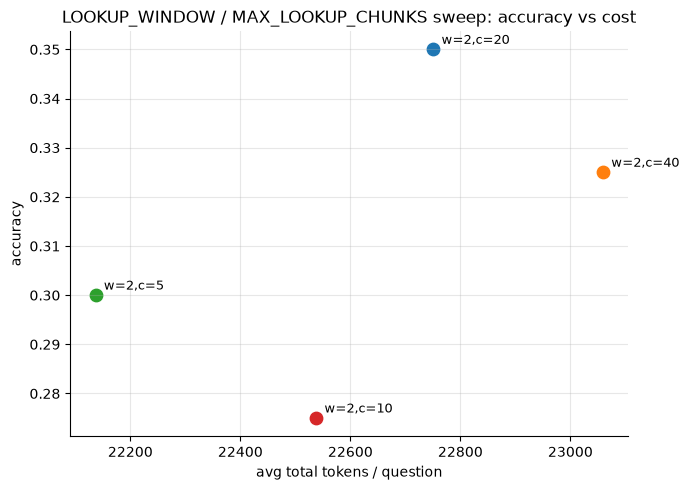

In [127]:
sweep_df = pd.read_csv(SWEEP_RESULTS_PATH, encoding="utf-8-sig") if os.path.exists(SWEEP_RESULTS_PATH) else pd.DataFrame()

if sweep_df.empty:
    print(f"No data yet in {SWEEP_RESULTS_PATH} -- set SWEEP_CONFIRM_SPEND = True above and run the sweep first.")
else:
    summary = sweep_df.groupby(["window", "cap"]).agg(
        accuracy=("correct", "mean"),
        avg_tokens=("total_tokens", "mean"),
        lookup_rate=("lookup_used", "mean"),
        n=("correct", "count"),
    ).reset_index()
    summary["score"] = summary["accuracy"] - SWEEP_COST_LAMBDA * (summary["avg_tokens"] / 10_000)
    summary = summary.sort_values("score", ascending=False)
    print(summary.to_string(index=False))

    fig, ax = plt.subplots(figsize=(7, 5))
    for _, r in summary.iterrows():
        ax.scatter(r["avg_tokens"], r["accuracy"], s=80)
        ax.annotate(f"w={r['window']},c={r['cap']}", (r["avg_tokens"], r["accuracy"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=9)
    ax.set_xlabel("avg total tokens / question")
    ax.set_ylabel("accuracy")
    ax.set_title("LOOKUP_WINDOW / MAX_LOOKUP_CHUNKS sweep: accuracy vs cost")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 13. Fourth condition — lookup+retrieval with a per-genre cap

Full-scale data (n=579 total, pooled across all conditions run so far)
consistently points one way for caselaw and another way for the rest:

- **caselaw** does *worse* with a bigger cap in every experiment run so
  far — the §12 sweep (c=5: 0.300, c=10: 0.200, c=20: 0.300, c=40:
  0.200 — noisy, but never rewards going bigger), the base lookup
  condition (c=5 pilot: 0.300 vs c=20 full-scale: 0.250), and
  lookup+retrieval at c=20 (0.245, the one genre retrieval augmentation
  didn't clearly help). The likely reason: caselaw is dense, boilerplate-
  heavy multiple-choice legal text, where more retrieved-but-approximate
  context is more likely to compete with the one correct passage than
  clarify it.
- **wiki/news/novel** all did at least as well at c=20 as at smaller caps
  in the §12 sweep, and lookup+retrieval's full-scale gains over plain
  lookup were largest exactly in these three genres.

One global `MAX_LOOKUP_CHUNKS` can't serve both patterns at once. This
condition reuses §10c's retrieval-augmented mechanism unchanged, except
the cap is looked up per genre instead of shared.

Kept as its own condition/results file, same as every mechanism change in
this notebook — §10's and §10c's already-collected full-scale results
stay untouched either way.


In [128]:
PER_GENRE_MAX_LOOKUP_CHUNKS = {
    "wiki": 20,
    "news": 20,
    "novel": 20,
    "caselaw": 5,
}
DEFAULT_MAX_LOOKUP_CHUNKS = 20


def _lookup_window_indices_pergenre(genre: str, targets: list[int], max_index: int) -> list[int]:
    """Same logic as _lookup_window_indices, but the cap is looked up per
    genre (PER_GENRE_MAX_LOOKUP_CHUNKS) instead of the single global
    MAX_LOOKUP_CHUNKS."""
    cap = PER_GENRE_MAX_LOOKUP_CHUNKS.get(genre, DEFAULT_MAX_LOOKUP_CHUNKS)
    selected: set[int] = set()
    for target in targets:
        window = set(range(max(0, target - LOOKUP_WINDOW), min(max_index, target + LOOKUP_WINDOW) + 1))
        if selected and len(selected | window) > cap:
            break
        selected |= window
    return sorted(selected)[:cap]


def run_full_context_rehearsal_lookup_retrieval_pergenre(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Identical to run_full_context_rehearsal_lookup_retrieval (\u00a710c),
    except window_indices is capped per genre instead of by one shared
    MAX_LOOKUP_CHUNKS."""
    fmt = GENRES[genre]["format"]
    answer_hint = "a number 1-5" if fmt == "multiple_choice" else "a short answer"
    rehearsed_chunks = full_gists_by_genre[genre]
    max_index = len(rehearsed_chunks) - 1

    system = {
        "role": "system",
        "content": (
            f"{_NO_TOOLS_SENTENCE} You are an assistant that answers questions. You will be shown a "
            f"gist of every chunk of the source text, each labelled with its chunk number. If you can "
            f"answer confidently from the gists, output {answer_hint}. If not, output "
            f"'LOOKUP: <chunk numbers>' naming one or more chunk numbers most likely to contain the "
            f"answer, and you will be shown their original text."
        ),
    }
    gist_block = {"role": "user", "content": _format_gist_list(rehearsed_chunks)}
    messages = [system, gist_block, _question_turn(genre, row)]

    total_elapsed = 0.0
    total_tokens = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
    api_calls = 0
    lookup_used = False

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    total_elapsed += time.time() - t0
    api_calls += 1
    usage = last_chat_usage() or {}
    for key in total_tokens:
        total_tokens[key] += usage.get(key) or 0

    lookup_targets = _parse_lookup_chunks(reply, max_index)

    if lookup_targets is None:
        candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
        prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)
    else:
        lookup_used = True
        retrieved = _embedding_top_k(genre, row["question"], EMBED_RETRIEVAL_TOP_K)
        related = [i for target in lookup_targets for i in _related_chunks(genre, target, RELATED_CHUNKS_TOP_M)]
        window_indices = _lookup_window_indices_pergenre(genre, lookup_targets + retrieved + related, max_index)
        raw_block = "\n\n".join(f"[chunk {i}]\n{rehearsed_chunks[i].original_text}" for i in window_indices)

        followup_system = {
            "role": "system",
            "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the original passage text below.",
        }
        followup_messages = [
            followup_system,
            {"role": "user", "content": f"Original passage text:\n\n{raw_block}"},
            _question_turn(genre, row),
        ]

        t0 = time.time()
        reply2 = call_chat(followup_messages, model=model, api_key=api_key, timeout=120.0)
        total_elapsed += time.time() - t0
        api_calls += 1
        usage = last_chat_usage() or {}
        for key in total_tokens:
            total_tokens[key] += usage.get(key) or 0

        candidate = parse_option_number(reply2) if fmt == "multiple_choice" else reply2.strip()
        prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else candidate

    return {
        "prediction": prediction,
        "api_calls": api_calls,
        "lookup_used": lookup_used,
        "elapsed_seconds": round(total_elapsed, 1),
        "prompt_tokens": total_tokens["prompt_tokens"],
        "completion_tokens": total_tokens["completion_tokens"],
        "total_tokens": total_tokens["total_tokens"],
    }


### Cost gate


In [129]:
PERGENRE_CONDITION = "full_context_rehearsal_lookup_retrieval_pergenre"
PERGENRE_RESULTS_PATH = "results/qa_stage2_rehearsal_lookup_retrieval_pergenre_condition.csv"
PERGENRE_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model
PERGENRE_PILOT_LIMIT = 20  # <- test at most this many NEW questions per genre; None = all

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions}, up to {2 * total_questions} QA calls (1-2 per question) "
      f"plus 1 query-embedding call per lookup-triggered question")
print(f"caps in use: {PER_GENRE_MAX_LOOKUP_CHUNKS}")
print(f"PERGENRE_CONFIRM_SPEND = {PERGENRE_CONFIRM_SPEND}   PERGENRE_PILOT_LIMIT = {PERGENRE_PILOT_LIMIT}")


questions: 579, up to 1158 QA calls (1-2 per question) plus 1 query-embedding call per lookup-triggered question
caps in use: {'wiki': 20, 'news': 20, 'novel': 20, 'caselaw': 5}
PERGENRE_CONFIRM_SPEND = True   PERGENRE_PILOT_LIMIT = 20


### Run the quiz


In [130]:
def _run_one_pergenre_question(genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_full_context_rehearsal_lookup_retrieval_pergenre(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": PERGENRE_CONDITION,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(PERGENRE_RESULTS_PATH):
    existing_pergenre_df = pd.read_csv(PERGENRE_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {PERGENRE_RESULTS_PATH} ({len(existing_pergenre_df)} rows)")
else:
    existing_pergenre_df = pd.DataFrame()

if not PERGENRE_CONFIRM_SPEND:
    print("skipped \u2014 PERGENRE_CONFIRM_SPEND is False")
    pergenre_df = existing_pergenre_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    pergenre_df = existing_pergenre_df
else:
    MAX_WORKERS_PERGENRE = 4
    results = existing_pergenre_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    for genre in GENRES:
        if genre not in full_gists_by_genre:
            print(f"skip (no precomputed gists): {genre}")
            continue
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:PERGENRE_PILOT_LIMIT] if PERGENRE_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"skip (already done): {genre}")
            continue

        print(f"running: {genre} ({len(todo_rows)} questions this batch, cap={PER_GENRE_MAX_LOOKUP_CHUNKS.get(genre, DEFAULT_MAX_LOOKUP_CHUNKS)})")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS_PERGENRE) as executor:
            futures = [executor.submit(_run_one_pergenre_question, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(PERGENRE_RESULTS_PATH, index=False)

    pergenre_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(pergenre_df)}")


running: wiki (20 questions this batch, cap=20)


wiki: 100%|██████████| 20/20 [00:12<00:00,  1.63it/s]


running: news (20 questions this batch, cap=20)


news: 100%|██████████| 20/20 [02:02<00:00,  6.13s/it]


running: novel (20 questions this batch, cap=20)


novel: 100%|██████████| 20/20 [08:41<00:00, 26.09s/it] 


  [novel] question 3e966645_1 failed: RuntimeError: NIM chat API call failed (retries exhausted): HTTPSConnectionPool(host='integrate.api.nvidia.com', port=443): Read timed out. (read timeout=120.0)
running: caselaw (20 questions this batch, cap=5)


caselaw: 100%|██████████| 20/20 [01:00<00:00,  3.02s/it]


total results: 80


### Compare against `full_context`, plain lookup, and lookup+retrieval (global cap)


genre       full_context    lookup  +retrieval  +retrieval(pergenre cap)
wiki               0.810     0.370       0.620                     0.750
news               0.395     0.105       0.220                     0.300
novel              0.494     0.203       0.291                     0.450
caselaw            0.360     0.250       0.245                     0.450


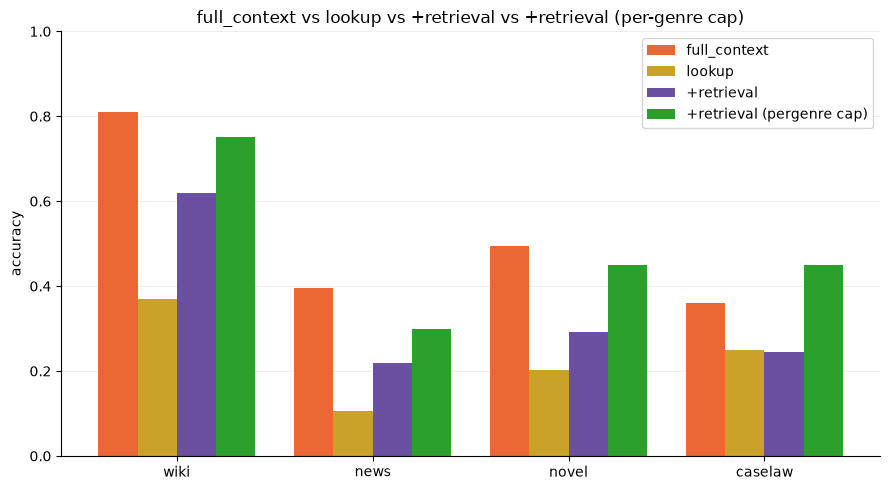

In [131]:
full_context_acc = baseline_df[baseline_df["condition"] == "full_context"].groupby("genre")["correct"].mean()
lookup_acc_cmp = pd.read_csv(LOOKUP_RESULTS_PATH, encoding="utf-8-sig").groupby("genre")["correct"].mean() if os.path.exists(LOOKUP_RESULTS_PATH) else pd.Series(dtype=float)
retrieval_acc_cmp = pd.read_csv(RETRIEVAL_RESULTS_PATH, encoding="utf-8-sig").groupby("genre")["correct"].mean() if os.path.exists(RETRIEVAL_RESULTS_PATH) else pd.Series(dtype=float)
pergenre_acc_cmp = pergenre_df.groupby("genre")["correct"].mean() if not pergenre_df.empty else pd.Series(dtype=float)

print(f"{'genre':10} {'full_context':>13} {'lookup':>9} {'+retrieval':>11} {'+retrieval(pergenre cap)':>25}")
for g in GENRE_ORDER:
    fc = full_context_acc.get(g, float("nan"))
    lk = lookup_acc_cmp.get(g, float("nan"))
    rt = retrieval_acc_cmp.get(g, float("nan"))
    pg = pergenre_acc_cmp.get(g)
    pg_str = f"{pg:.3f}" if pg is not None else "(no data yet)"
    print(f"{g:10} {fc:>13.3f} {lk:>9.3f} {rt:>11.3f} {pg_str:>25}")

_series_to_plot = {
    "full_context": full_context_acc,
    "lookup": lookup_acc_cmp,
    "+retrieval": retrieval_acc_cmp,
    "+retrieval (pergenre cap)": pergenre_acc_cmp,
}
_bar_colors = ["#eb6834", "#c9a227", "#6b4fa0", "#2ca02c"]

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(GENRE_ORDER))
bar_width = 0.8 / len(_series_to_plot)
for i, (label, series) in enumerate(_series_to_plot.items()):
    values = [series.get(g, float("nan")) for g in GENRE_ORDER]
    ax.bar([xi + i * bar_width for xi in x], values, width=bar_width, label=label, color=_bar_colors[i])
ax.set_xticks([xi + bar_width * (len(_series_to_plot) - 1) / 2 for xi in x])
ax.set_xticklabels(GENRE_ORDER)
ax.set_ylabel("accuracy")
ax.set_ylim(0, 1)
ax.set_title("full_context vs lookup vs +retrieval vs +retrieval (per-genre cap)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)
ax.legend()
plt.tight_layout()
plt.show()


## 14. Fifth condition — adaptive-k lookup (generalizable, no per-genre tuning)

Section 13's per-genre cap worked empirically but doesn't generalize --
`PER_GENRE_MAX_LOOKUP_CHUNKS` is a lookup table keyed by these 4 genres'
names specifically. On a 5th genre it would fall back to a guessed default,
which is exactly the "one fixed number for everything" problem this was
supposed to fix in the first place, just deferred to a new domain.

This condition replaces every fixed-count expansion signal built so far
(the ±`LOOKUP_WINDOW` position window, `_embedding_top_k`'s fixed top-K,
`_related_chunks`'s fixed top-M, and §13's per-genre cap) with one
mechanism, following Adaptive-k (arXiv:2506.08479, cited earlier this
session): **how many chunks to show is decided by the shape of this
specific question's own similarity-score distribution, not a fixed count
or a category lookup.**

1. Embed the question once; score every chunk in the document by
   similarity to it (reuses `chunk_embeddings_by_genre` from §10c --
   no new precompute).
2. Keep whichever chunks score within `ADAPTIVE_RELATIVE_THRESHOLD` of the
   top score. A steep score drop-off after 1-2 chunks (e.g. caselaw's dense,
   boilerplate-heavy passages, where usually only one passage is actually
   on-topic) naturally selects few; a gradual decline (e.g. novel, where
   relevant context can be spread across a scene) naturally selects more --
   the mechanism reacts to the data, it does not need to be told which
   genre it's looking at.
3. Union with a small fixed window (`ADAPTIVE_TARGET_WINDOW`) around
   whatever chunk(s) the model itself named -- its own reasoning-based
   pointer is a distinct signal from pure embedding similarity and
   shouldn't be discarded by the threshold alone.
4. `ADAPTIVE_SAFETY_CAP` is a hard ceiling, not a tuned value -- it exists
   only to bound the worst case if a document's score distribution is
   pathologically flat (many chunks all scoring similarly), not to encode
   anything about a specific genre.


In [132]:
ADAPTIVE_RELATIVE_THRESHOLD = 0.85  # keep chunks scoring within this fraction of the top similarity score
ADAPTIVE_TARGET_WINDOW = 1  # small fixed window around the model's own named chunk(s), always included
ADAPTIVE_SAFETY_CAP = 40  # hard ceiling regardless of how many chunks pass the threshold -- a safety bound, not a tuned value


def _adaptive_chunk_selection(scored: list[tuple[int, float]], relative_threshold: float, safety_cap: int) -> list[int]:
    """Adaptive-k (arXiv:2506.08479): how many chunks are 'good enough' is
    decided by the shape of this question's own similarity-score
    distribution, not a fixed count or a per-genre table -- generalizes to
    any new document/domain without retuning."""
    if not scored:
        return []
    ranked = sorted(scored, key=lambda x: x[1], reverse=True)
    top_score = ranked[0][1]
    if top_score <= 0:
        return [ranked[0][0]]
    cutoff = top_score * relative_threshold
    selected = [i for i, score in ranked if score >= cutoff]
    return selected[:safety_cap]


def run_full_context_rehearsal_lookup_adaptive(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Same first call as the other lookup conditions. When lookup triggers,
    the raw chunks shown are chosen adaptively -- see \u00a714's header --
    instead of by any fixed count or genre-keyed table."""
    fmt = GENRES[genre]["format"]
    answer_hint = "a number 1-5" if fmt == "multiple_choice" else "a short answer"
    rehearsed_chunks = full_gists_by_genre[genre]
    max_index = len(rehearsed_chunks) - 1

    system = {
        "role": "system",
        "content": (
            f"{_NO_TOOLS_SENTENCE} You are an assistant that answers questions. You will be shown a "
            f"gist of every chunk of the source text, each labelled with its chunk number. If you can "
            f"answer confidently from the gists, output {answer_hint}. If not, output "
            f"'LOOKUP: <chunk numbers>' naming one or more chunk numbers most likely to contain the "
            f"answer, and you will be shown their original text."
        ),
    }
    gist_block = {"role": "user", "content": _format_gist_list(rehearsed_chunks)}
    messages = [system, gist_block, _question_turn(genre, row)]

    total_elapsed = 0.0
    total_tokens = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
    api_calls = 0
    lookup_used = False

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    total_elapsed += time.time() - t0
    api_calls += 1
    usage = last_chat_usage() or {}
    for key in total_tokens:
        total_tokens[key] += usage.get(key) or 0

    lookup_targets = _parse_lookup_chunks(reply, max_index)

    if lookup_targets is None:
        candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
        prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)
    else:
        lookup_used = True

        query_embedding = embed_with_retry([row["question"]], "query", embed_cfg, embed_texts)
        if query_embedding is not None and genre in chunk_embeddings_by_genre:
            scored = [(i, cosine_similarity(query_embedding[0], emb)) for i, emb in enumerate(chunk_embeddings_by_genre[genre])]
            adaptive_selected = _adaptive_chunk_selection(scored, ADAPTIVE_RELATIVE_THRESHOLD, ADAPTIVE_SAFETY_CAP)
        else:
            adaptive_selected = []

        target_window: set[int] = set()
        for target in lookup_targets:
            target_window |= set(range(max(0, target - ADAPTIVE_TARGET_WINDOW), min(max_index, target + ADAPTIVE_TARGET_WINDOW) + 1))

        window_indices = sorted(set(adaptive_selected) | target_window)[:ADAPTIVE_SAFETY_CAP]
        raw_block = "\n\n".join(f"[chunk {i}]\n{rehearsed_chunks[i].original_text}" for i in window_indices)

        followup_system = {
            "role": "system",
            "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the original passage text below.",
        }
        followup_messages = [
            followup_system,
            {"role": "user", "content": f"Original passage text:\n\n{raw_block}"},
            _question_turn(genre, row),
        ]

        t0 = time.time()
        reply2 = call_chat(followup_messages, model=model, api_key=api_key, timeout=120.0)
        total_elapsed += time.time() - t0
        api_calls += 1
        usage = last_chat_usage() or {}
        for key in total_tokens:
            total_tokens[key] += usage.get(key) or 0

        candidate = parse_option_number(reply2) if fmt == "multiple_choice" else reply2.strip()
        prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else candidate

    return {
        "prediction": prediction,
        "api_calls": api_calls,
        "lookup_used": lookup_used,
        "elapsed_seconds": round(total_elapsed, 1),
        "prompt_tokens": total_tokens["prompt_tokens"],
        "completion_tokens": total_tokens["completion_tokens"],
        "total_tokens": total_tokens["total_tokens"],
    }


### Cost gate


In [136]:
ADAPTIVE_CONDITION = "full_context_rehearsal_lookup_adaptive"
ADAPTIVE_RESULTS_PATH = "results/qa_stage2_rehearsal_lookup_adaptive_condition.csv"
ADAPTIVE_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model
ADAPTIVE_PILOT_LIMIT = 20  # <- test at most this many NEW questions per genre; None = all

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions}, up to {2 * total_questions} QA calls (1-2 per question) "
      f"plus 1 query-embedding call per lookup-triggered question")
print(f"ADAPTIVE_RELATIVE_THRESHOLD = {ADAPTIVE_RELATIVE_THRESHOLD}   ADAPTIVE_SAFETY_CAP = {ADAPTIVE_SAFETY_CAP}")
print(f"ADAPTIVE_CONFIRM_SPEND = {ADAPTIVE_CONFIRM_SPEND}   ADAPTIVE_PILOT_LIMIT = {ADAPTIVE_PILOT_LIMIT}")


questions: 579, up to 1158 QA calls (1-2 per question) plus 1 query-embedding call per lookup-triggered question
ADAPTIVE_RELATIVE_THRESHOLD = 0.85   ADAPTIVE_SAFETY_CAP = 40
ADAPTIVE_CONFIRM_SPEND = True   ADAPTIVE_PILOT_LIMIT = 20


### Run the quiz


In [137]:
def _run_one_adaptive_question(genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_full_context_rehearsal_lookup_adaptive(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": ADAPTIVE_CONDITION,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(ADAPTIVE_RESULTS_PATH):
    existing_adaptive_df = pd.read_csv(ADAPTIVE_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {ADAPTIVE_RESULTS_PATH} ({len(existing_adaptive_df)} rows)")
else:
    existing_adaptive_df = pd.DataFrame()

if not ADAPTIVE_CONFIRM_SPEND:
    print("skipped \u2014 ADAPTIVE_CONFIRM_SPEND is False")
    adaptive_df = existing_adaptive_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    adaptive_df = existing_adaptive_df
else:
    MAX_WORKERS_ADAPTIVE = 4
    results = existing_adaptive_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    for genre in GENRES:
        if genre not in full_gists_by_genre:
            print(f"skip (no precomputed gists): {genre}")
            continue
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:ADAPTIVE_PILOT_LIMIT] if ADAPTIVE_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"skip (already done): {genre}")
            continue

        print(f"running: {genre} ({len(todo_rows)} questions this batch)")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS_ADAPTIVE) as executor:
            futures = [executor.submit(_run_one_adaptive_question, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(ADAPTIVE_RESULTS_PATH, index=False)

    adaptive_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(adaptive_df)}")


running: wiki (20 questions this batch)


wiki: 100%|██████████| 20/20 [00:08<00:00,  2.43it/s]


running: news (20 questions this batch)


news: 100%|██████████| 20/20 [01:56<00:00,  5.85s/it]


running: novel (20 questions this batch)


novel: 100%|██████████| 20/20 [02:54<00:00,  8.75s/it]


running: caselaw (20 questions this batch)


caselaw: 100%|██████████| 20/20 [00:26<00:00,  1.34s/it]


total results: 80


### Compare against `full_context` and every prior condition

Also reports how many chunks the adaptive selection actually chose per
genre, on average -- the number that matters for judging whether it's
behaving sensibly is *this*, not a target accuracy: it should come out
small for caselaw-like cases and larger elsewhere, on its own, without
being told which genre it's looking at.


In [138]:
full_context_acc = baseline_df[baseline_df["condition"] == "full_context"].groupby("genre")["correct"].mean()
lookup_acc_cmp2 = pd.read_csv(LOOKUP_RESULTS_PATH, encoding="utf-8-sig").groupby("genre")["correct"].mean() if os.path.exists(LOOKUP_RESULTS_PATH) else pd.Series(dtype=float)
retrieval_acc_cmp2 = pd.read_csv(RETRIEVAL_RESULTS_PATH, encoding="utf-8-sig").groupby("genre")["correct"].mean() if os.path.exists(RETRIEVAL_RESULTS_PATH) else pd.Series(dtype=float)
pergenre_acc_cmp2 = pd.read_csv(PERGENRE_RESULTS_PATH, encoding="utf-8-sig").groupby("genre")["correct"].mean() if os.path.exists(PERGENRE_RESULTS_PATH) else pd.Series(dtype=float)
adaptive_acc_cmp = adaptive_df.groupby("genre")["correct"].mean() if not adaptive_df.empty else pd.Series(dtype=float)

print(f"{'genre':10} {'full_context':>13} {'lookup':>9} {'+retrieval':>11} {'+pergenre':>10} {'+adaptive':>10}")
for g in GENRE_ORDER:
    fc = full_context_acc.get(g, float("nan"))
    lk = lookup_acc_cmp2.get(g, float("nan"))
    rt = retrieval_acc_cmp2.get(g, float("nan"))
    pg = pergenre_acc_cmp2.get(g, float("nan"))
    ad = adaptive_acc_cmp.get(g, float("nan"))
    print(f"{g:10} {fc:>13.3f} {lk:>9.3f} {rt:>11.3f} {pg:>10.3f} {ad:>10.3f}")

if not adaptive_df.empty:
    triggered = adaptive_df[adaptive_df["lookup_used"] == True]
    if not triggered.empty:
        avg_tokens_triggered = triggered.groupby("genre")["total_tokens"].mean()
        print("\navg total tokens on lookup-triggered questions, by genre (proxy for how many chunks the adaptive selection chose):")
        print(avg_tokens_triggered)


genre       full_context    lookup  +retrieval  +pergenre  +adaptive
wiki               0.810     0.370       0.620      0.750      0.750
news               0.395     0.105       0.220      0.300      0.300
novel              0.494     0.203       0.291      0.450      0.450
caselaw            0.360     0.250       0.245      0.450      0.300

avg total tokens on lookup-triggered questions, by genre (proxy for how many chunks the adaptive selection chose):
genre
caselaw    34368.666667
news       28637.235294
novel      33553.200000
wiki        8994.800000
Name: total_tokens, dtype: float64


## 15. Compare all conditions

Loads `03`'s three baseline conditions plus both conditions built in this
notebook (`chunked_sequential_rehearsal` from §7, `full_context_rehearsal_lookup`
from §10) into one combined table. Everything below — the accuracy table
and all four plots — reads from this single `combined` DataFrame, so a
condition missing here means every plot below is missing it too.


In [120]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

CONDITIONS_ORDER = [
    "closed_book",
    "full_context",
    "chunked_sequential",
    "chunked_sequential_rehearsal",
    "full_context_rehearsal_lookup",
    "full_context_rehearsal_lookup_retrieval",
    "full_context_rehearsal_lookup_retrieval_pergenre",
    "full_context_rehearsal_lookup_adaptive",
]
CONDITION_COLORS = {
    "closed_book": "#2a78d6",
    "full_context": "#eb6834",
    "chunked_sequential": "#1baf7a",
    "chunked_sequential_rehearsal": "#a83279",
    "full_context_rehearsal_lookup": "#c9a227",
    "full_context_rehearsal_lookup_retrieval": "#6b4fa0",
    "full_context_rehearsal_lookup_retrieval_pergenre": "#2ca02c",
    "full_context_rehearsal_lookup_adaptive": "#d6336c",
}
GENRE_ORDER = list(GENRES.keys())

baseline_df = pd.read_csv("results/qa_baseline_3conditions.csv", encoding="utf-8-sig")
rehearsal_path = Path("results/qa_stage2_rehearsal_condition.csv")
rehearsal_df = pd.read_csv(rehearsal_path, encoding="utf-8-sig") if rehearsal_path.exists() else pd.DataFrame()
lookup_path = Path("results/qa_stage2_rehearsal_lookup_condition.csv")
lookup_df = pd.read_csv(lookup_path, encoding="utf-8-sig") if lookup_path.exists() else pd.DataFrame()
retrieval_path = Path("results/qa_stage2_rehearsal_lookup_retrieval_condition.csv")
retrieval_df = pd.read_csv(retrieval_path, encoding="utf-8-sig") if retrieval_path.exists() else pd.DataFrame()
pergenre_path = Path("results/qa_stage2_rehearsal_lookup_retrieval_pergenre_condition.csv")
pergenre_df = pd.read_csv(pergenre_path, encoding="utf-8-sig") if pergenre_path.exists() else pd.DataFrame()
adaptive_path = Path("results/qa_stage2_rehearsal_lookup_adaptive_condition.csv")
adaptive_df = pd.read_csv(adaptive_path, encoding="utf-8-sig") if adaptive_path.exists() else pd.DataFrame()

combined = pd.concat([baseline_df, rehearsal_df, lookup_df, retrieval_df, pergenre_df, adaptive_df], ignore_index=True)
combined = combined[combined["condition"].isin(CONDITIONS_ORDER)]

accuracy = combined.pivot_table(index="genre", columns="condition", values="correct", aggfunc="mean")
accuracy = accuracy.reindex(GENRE_ORDER)[[c for c in CONDITIONS_ORDER if c in accuracy.columns]]
n = combined.pivot_table(index="genre", columns="condition", values="correct", aggfunc="count")
n = n.reindex(GENRE_ORDER)[[c for c in CONDITIONS_ORDER if c in n.columns]]
print("accuracy:")
print(accuracy)
print("\nn:")
print(n)

if not lookup_df.empty:
    print("\nlookup triggered rate by genre (base lookup condition):")
    print(lookup_df.groupby("genre")["lookup_used"].mean())
if not retrieval_df.empty:
    print("\nlookup triggered rate by genre (retrieval-augmented condition):")
    print(retrieval_df.groupby("genre")["lookup_used"].mean())

accuracy:
condition  closed_book  full_context  chunked_sequential  \
genre                                                      
wiki          0.280000      0.810000            0.190000   
news          0.040000      0.395000            0.010000   
novel         0.025316      0.493671            0.063291   
caselaw       0.335000      0.360000            0.225000   

condition  chunked_sequential_rehearsal  full_context_rehearsal_lookup  \
genre                                                                    
wiki                           0.230000                       0.370000   
news                           0.010000                       0.105000   
novel                          0.050633                       0.202532   
caselaw                        0.185000                       0.250000   

condition  full_context_rehearsal_lookup_retrieval  
genre                                               
wiki                                      0.620000  
news                     

## Accuracy by genre x condition

Two pairs matter here, same budget/prompts within each pair: `chunked_sequential`
vs `chunked_sequential_rehearsal` (does B alone beat the uncompressed control?)
and `full_context` vs `full_context_rehearsal_lookup` (does B + lookup close the
larger gap against the lossless baseline?). `closed_book` is a floor, not a test.


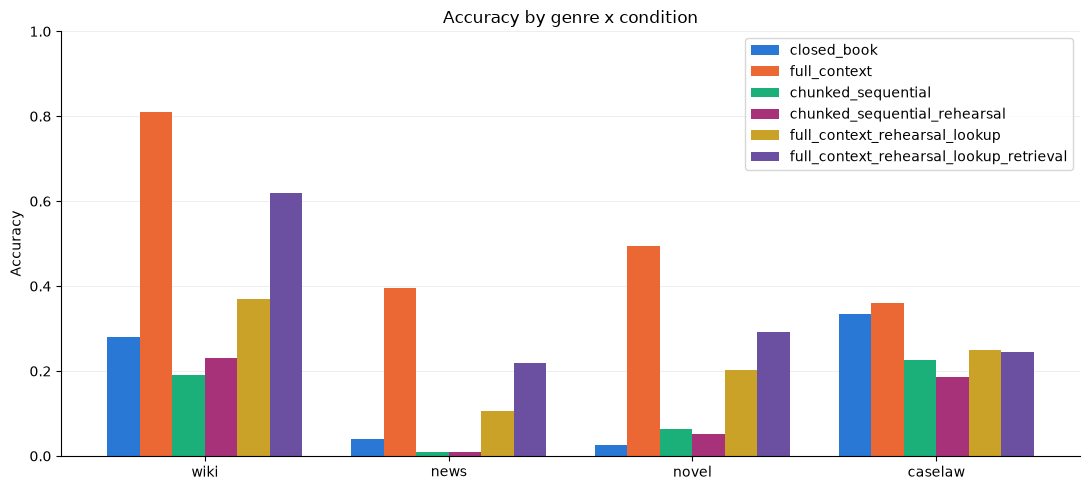

In [148]:
accuracy = combined.pivot_table(index="genre", columns="condition", values="correct", aggfunc="mean")
accuracy = accuracy.reindex(GENRE_ORDER)[[c for c in CONDITIONS_ORDER if c in accuracy.columns]]

x = range(len(accuracy))
bar_width = 0.8 / len(accuracy.columns)
fig, ax = plt.subplots(figsize=(11, 5))
for i, condition in enumerate(accuracy.columns):
    ax.bar([xi + i * bar_width for xi in x], accuracy[condition], width=bar_width,
           label=condition, color=CONDITION_COLORS[condition])
ax.set_xticks([xi + bar_width * (len(accuracy.columns) - 1) / 2 for xi in x])
ax.set_xticklabels(accuracy.index)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by genre x condition")
ax.set_ylim(0, 1)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)
ax.legend()
plt.tight_layout()
plt.show()

## Accuracy per token — accuracy / efficiency

Raw accuracy alone hides cost, and the token-cost plot alone hides
accuracy -- this divides one by the other so a condition that's cheap
*and* accurate stands out directly, `full_context` included (it has the
highest accuracy almost everywhere, but pays for it in tokens more than
anything else here).


accuracy per 10,000 tokens, by genre x condition:
condition  full_context  chunked_sequential  chunked_sequential_rehearsal  full_context_rehearsal_lookup  full_context_rehearsal_lookup_retrieval
genre                                                                                                                                            
wiki              0.414               0.426                         1.317                          0.425                                    0.636
news              0.061               0.033                         0.054                          0.040                                    0.082
novel             0.061               0.247                         0.286                          0.065                                    0.093
caselaw           0.041               0.600                         0.775                          0.098                                    0.093


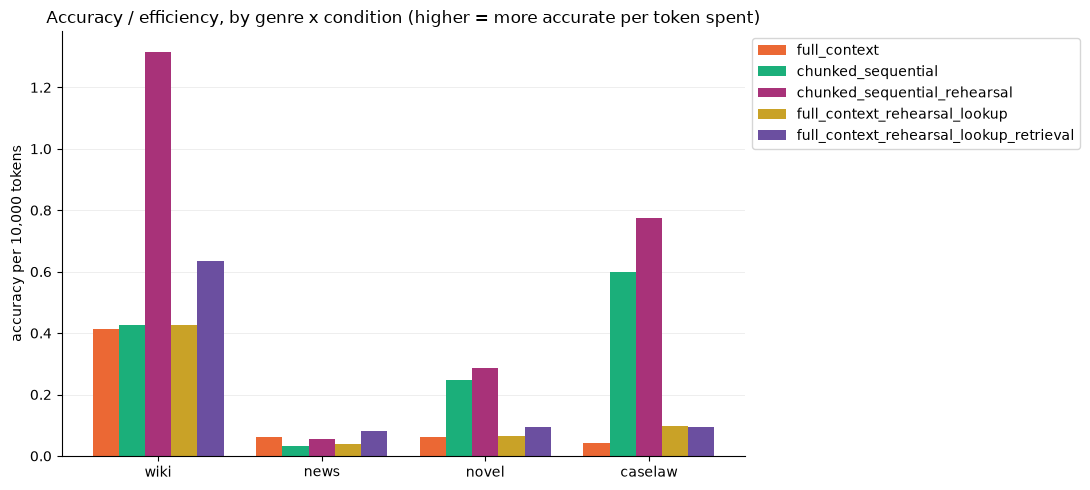

In [153]:
EFFICIENCY_CONDITIONS = [c for c in CONDITIONS_ORDER if c != "closed_book"]  # excluded: near-zero tokens makes its ratio a meaningless outlier, and it never reads the document anyway

tokens_by_genre_condition = combined.pivot_table(index="genre", columns="condition", values="total_tokens", aggfunc="mean")
tokens_by_genre_condition = tokens_by_genre_condition.reindex(GENRE_ORDER)[[c for c in EFFICIENCY_CONDITIONS if c in tokens_by_genre_condition.columns]]

# accuracy per 10,000 tokens -- raw accuracy/tokens is a tiny number (tokens are in the tens of thousands), scaled for readability
accuracy_for_efficiency = accuracy[[c for c in EFFICIENCY_CONDITIONS if c in accuracy.columns]]
accuracy_per_10k_tokens = accuracy_for_efficiency / tokens_by_genre_condition * 10_000
print("accuracy per 10,000 tokens, by genre x condition:")
print(accuracy_per_10k_tokens.round(3).to_string())

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(accuracy_per_10k_tokens))
bar_width = 0.8 / len(accuracy_per_10k_tokens.columns)
for i, condition in enumerate(accuracy_per_10k_tokens.columns):
    ax.bar([xi + i * bar_width for xi in x], accuracy_per_10k_tokens[condition], width=bar_width,
           label=condition, color=CONDITION_COLORS[condition])
ax.set_xticks([xi + bar_width * (len(accuracy_per_10k_tokens.columns) - 1) / 2 for xi in x])
ax.set_xticklabels(accuracy_per_10k_tokens.index)
ax.set_ylabel("accuracy per 10,000 tokens")
ax.set_title("Accuracy / efficiency, by genre x condition (higher = more accurate per token spent)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()


## Accuracy by evidence position in the document

`chunked_sequential` only ever sees the first 4 chunks — so its accuracy
should fall off as the evidence sits further into the document, and that
fall-off is exactly what compression is supposed to soften: if B's rolling
memory carries earlier material forward, `chunked_sequential_rehearsal`
should decay more slowly across the same 10/30/50/70/90% bins, not just
score higher on average. `closed_book`/`full_context` are plotted as
reference lines — closed_book should be roughly flat (it never reads the
document, so position shouldn't matter), and a clearly non-flat closed_book
line would be a sign of some question-set imbalance worth checking rather
than a real effect.

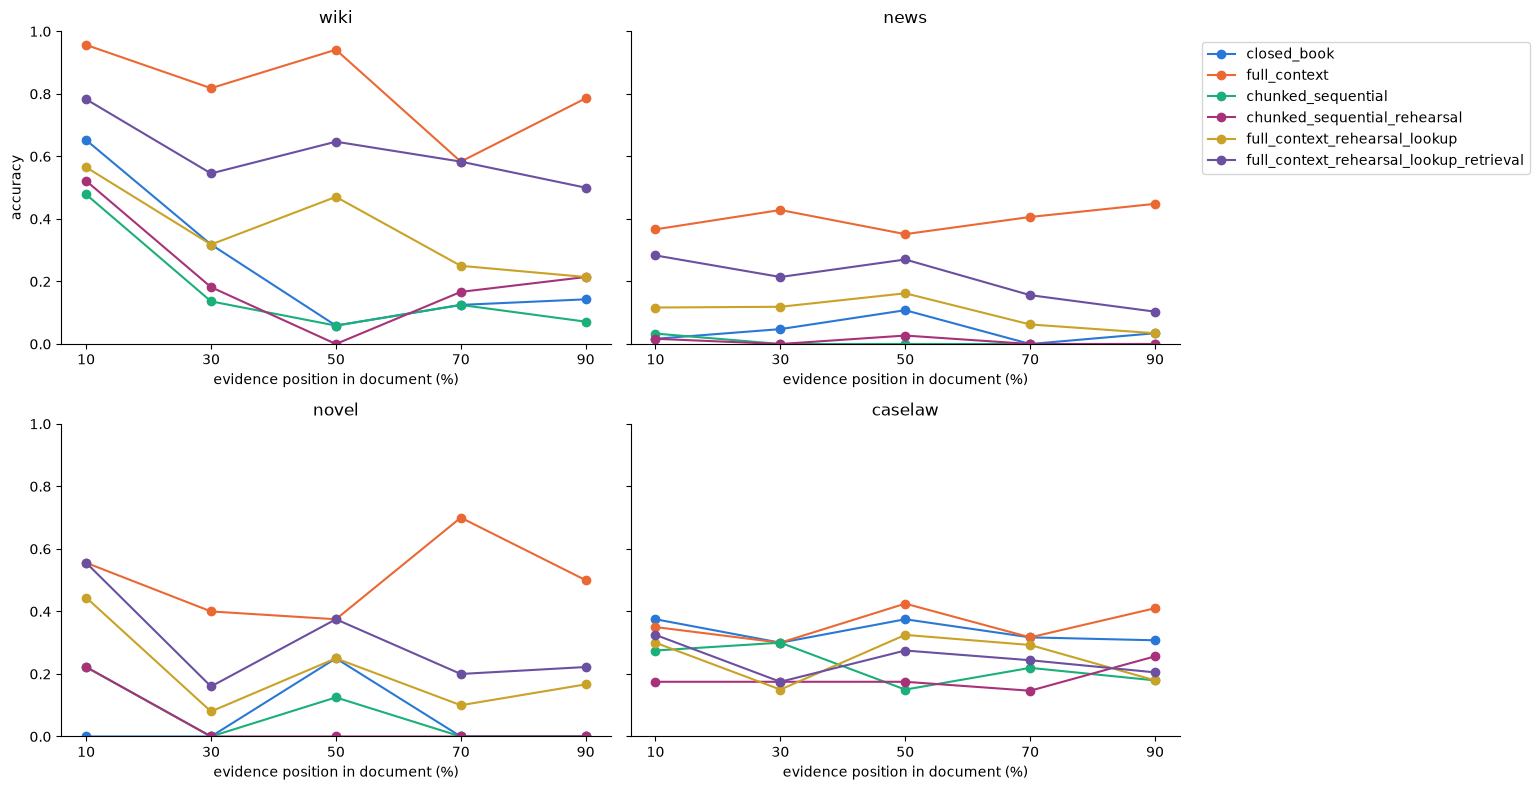

In [150]:
def evidence_fraction(genre: str, question_id) -> float | None:
    qdf = questions[genre]
    if "evidence_char_pos" not in qdf.columns:
        return None
    row = qdf[qdf["question_id"].astype(str) == str(question_id)]
    if row.empty or pd.isna(row["evidence_char_pos"].iloc[0]):
        return None
    return row["evidence_char_pos"].iloc[0] / len(corpora[genre])

combined["position_frac"] = combined.apply(
    lambda r: evidence_fraction(r["genre"], r["question_id"]), axis=1
)

bin_edges = [0, 0.2, 0.4, 0.6, 0.8, 1.0001]
bin_labels = [10, 30, 50, 70, 90]
combined["position_bin"] = pd.cut(
    combined["position_frac"], bins=bin_edges, labels=bin_labels, include_lowest=True
)

n_genres = len(GENRE_ORDER)
ncols = 2
nrows = -(-n_genres // ncols)  # ceil
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharey=True)
axes = axes.flatten()
for ax, genre in zip(axes, GENRE_ORDER):
    sub = combined[combined["genre"] == genre]
    for condition in CONDITIONS_ORDER:
        cond_sub = sub[sub["condition"] == condition]
        if cond_sub.empty:
            continue
        acc_by_bin = cond_sub.groupby("position_bin", observed=True)["correct"].mean().reindex(bin_labels)
        ax.plot(bin_labels, acc_by_bin.values, marker="o", label=condition, color=CONDITION_COLORS[condition])
    ax.set_title(genre)
    ax.set_xlabel("evidence position in document (%)")
    ax.set_xticks(bin_labels)
    ax.set_ylim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes[n_genres:]:
    ax.set_visible(False)
axes[0].set_ylabel("accuracy")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(1.0, 0.95))
plt.tight_layout()
plt.show()

## Efficiency by genre, across methods

Same read as `03`'s own efficiency table (§7 there), extended to the new
condition: cost isn't free, so a method that wins on accuracy only matters
if the cost it adds is proportionate. `chunked_sequential_rehearsal` pays
for compression up front (the §3 precompute) but *shows* less text per step
than raw `chunked_sequential` — whether that nets out cheaper or more
expensive per question is genre-dependent and worth reading directly off
this rather than assuming either direction.

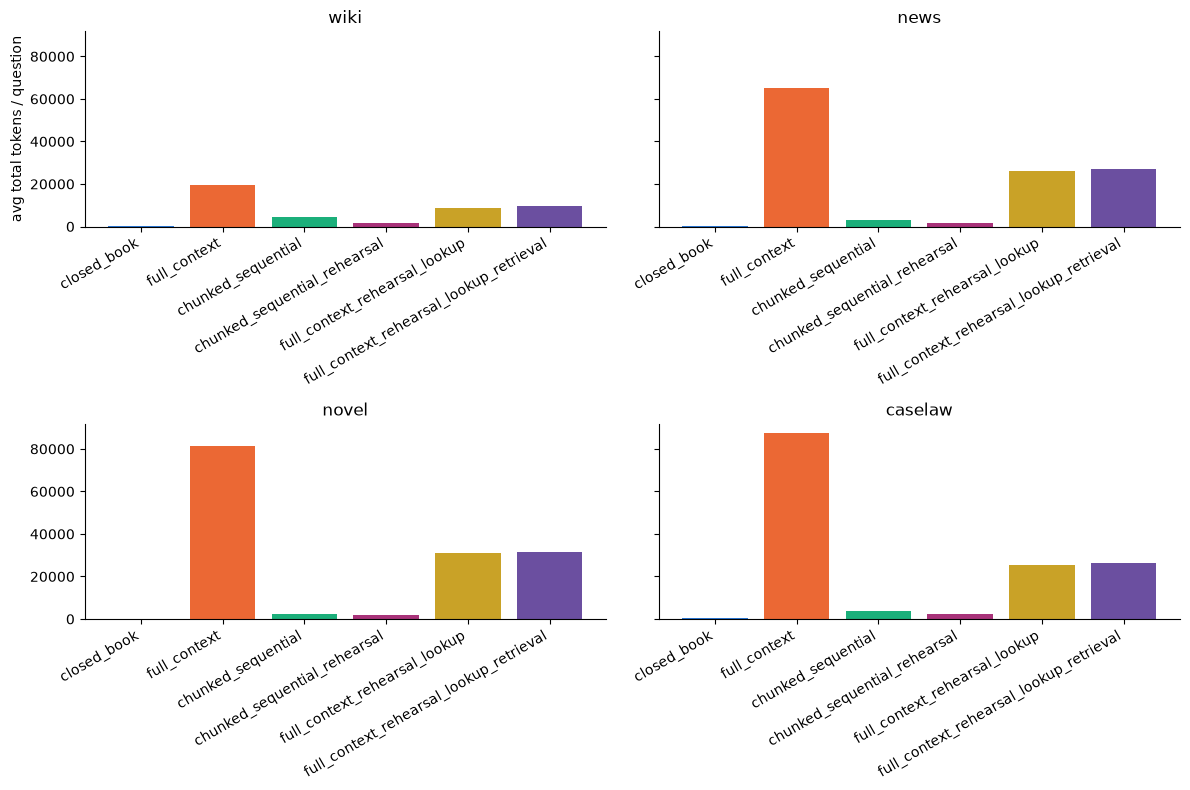

In [151]:
efficiency = combined.groupby(["genre", "condition"]).agg(
    avg_tokens=("total_tokens", "mean"),
    avg_api_calls=("api_calls", "mean"),
    avg_seconds=("elapsed_seconds", "mean"),
).reset_index()

n_genres = len(GENRE_ORDER)
ncols = 2
nrows = -(-n_genres // ncols)  # ceil
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharey=True)
axes = axes.flatten()
for ax, genre in zip(axes, GENRE_ORDER):
    sub = efficiency[efficiency["genre"] == genre].set_index("condition").reindex(
        [c for c in CONDITIONS_ORDER if c in efficiency["condition"].unique()]
    )
    ax.bar(range(len(sub)), sub["avg_tokens"], color=[CONDITION_COLORS[c] for c in sub.index])
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub.index, rotation=30, ha="right")
    ax.set_title(genre)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes[n_genres:]:
    ax.set_visible(False)
axes[0].set_ylabel("avg total tokens / question")
plt.tight_layout()
plt.show()

## Efficiency by method, across genres

Same numbers as Plot 3, transposed — this view is for spotting whether a
method's cost is roughly stable across genres (expected, since the chunk/
step budget is fixed at 4 everywhere) or whether one genre is a cost outlier
(e.g. caselaw's multiple-choice prompts are shaped differently from the
extractive genres', so its token count isn't directly comparable to the
other three even under the same method).

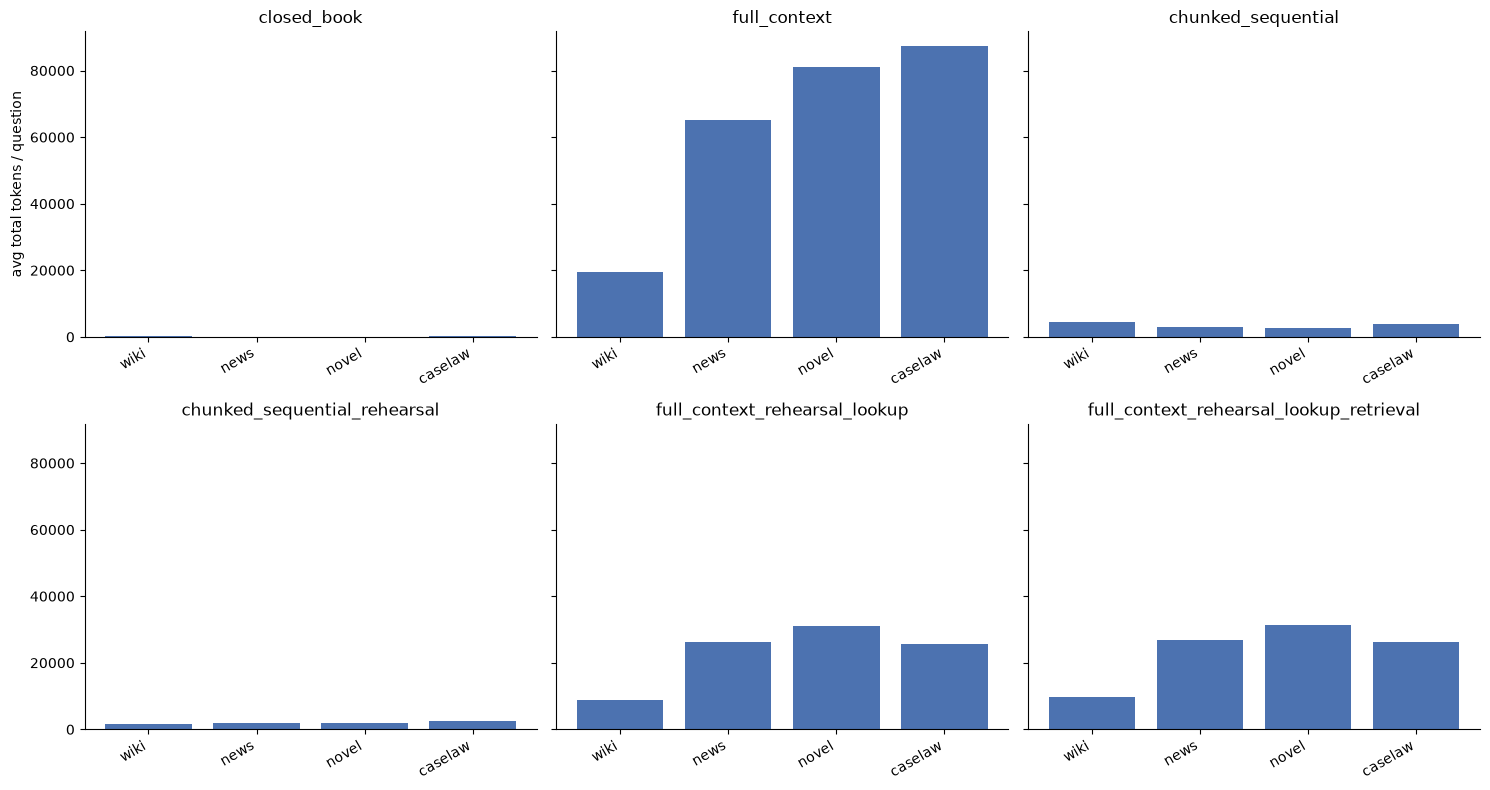

In [152]:
conditions_present = [c for c in CONDITIONS_ORDER if c in efficiency["condition"].unique()]

n_cond = len(conditions_present)
ncols = min(3, n_cond)  # up to 3 per row
nrows = -(-n_cond // ncols)  # ceil
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True)
axes = axes.flatten() if n_cond > 1 else [axes]
for ax, condition in zip(axes, conditions_present):
    sub = efficiency[efficiency["condition"] == condition].set_index("genre").reindex(GENRE_ORDER)
    ax.bar(range(len(sub)), sub["avg_tokens"], color="#4c72b0")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub.index, rotation=30, ha="right")
    ax.set_title(condition)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes[n_cond:]:
    ax.set_visible(False)
axes[0].set_ylabel("avg total tokens / question")
plt.tight_layout()
plt.show()

## Summary

What to read here, and what not to over-read.

- **Two new conditions were tested against `03`'s baseline**:
  `chunked_sequential_rehearsal` (B alone, §7, full 579-question run) and
  `full_context_rehearsal_lookup` (B + ReadAgent-P style lookup, §10 — check
  the `n` column above before treating a genre as settled, it may still be
  pilot-scale via `LOOKUP_PILOT_LIMIT`).
- **`chunked_sequential_rehearsal` vs `chunked_sequential`** decides whether
  stage 2 training was worth it on uncompressed-vs-compressed terms.
  **`full_context_rehearsal_lookup` vs `full_context`** decides whether
  lookup closes the larger gap: at these corpus sizes `full_context` loses
  no information (nothing is truncated), so beating it requires winning on
  attention/navigation, not on having more information available.
- **A real bug was found and fixed in the lookup condition** (§8/§9): the
  second call was resending the entire per-chunk gist block as conversation
  history, roughly doubling prompt tokens and burying the actually-useful
  raw text behind duplicate noise — accuracy on lookup-triggered questions
  measured 0.0-0.30 pre-fix, far below both `full_context` and the
  non-triggered path. Fixed by making the second call a fresh, short prompt;
  `MAX_LOOKUP_CHUNKS = 5` caps how many chunks one lookup can pull in.
  Confirm the results CSV postdates the fix (delete and re-run after any
  change to `run_full_context_rehearsal_lookup`) before trusting these numbers.
- **`07b`'s own caveat carries over to both conditions.** Stage 2 has a real,
  positive collapse signature (drop +0.111) despite being 5-6x better than
  stage 1 at every age — both conditions inherit whatever ceiling that puts
  on gist quality.
- **Caselaw caveat inherited from `03`/`06b`.** The CaseHOLD *eval* corpus
  still contains the literal `<HOLDING>` placeholder token (only stripped
  from the *train* corpora) — gists for caselaw in both conditions are
  generated from source text with that artifact still present.
- **Sample sizes**: `chunked_sequential_rehearsal` matches `03`'s full sizes
  (wiki 100, news 200, novel 79, caselaw 200). `full_context_rehearsal_lookup`
  is pilot-scale until run at full scale.
- **Scope**: both conditions test B (elaborative) only — A (maintenance),
  A->B, and lookup combined with either, are separate, not-yet-built grid
  cells (see §8's scope note).
- **`LOOKUP_WINDOW`/`MAX_LOOKUP_CHUNKS` tuning**: see the grid sweep above (§12) — both were first-guess values until swept.
- **Third condition (§10c)**: `full_context_rehearsal_lookup_retrieval` augments the model's own chunk-number guess with embedding-similarity retrieval, targeting a specific failure mode the base lookup condition's data showed (news: triggers lookup 75% of the time but only 0.2 accuracy after — a wrong-chunk-targeting problem, not a token-budget problem). Not yet run — gated behind `RETRIEVAL_CONFIRM_SPEND`.
